# Análisis Exploratorio de Datos (EDA)
## Dataset: `p18.src_transaccion_diario`

**Objetivo:** Entender el comportamiento del dataset de transacciones diarias de P18, identificando patrones de cargos, abonos y saldos de cuentas, distribuciones temporales, tipos de concepto y anomalías en los datos.

---

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:,.4f}'.format)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga del Dataset

In [2]:
FILE_PATH = 'p18.src_transaccion_diario.csv'

df = pd.read_csv(
    FILE_PATH,
    sep=';',
    encoding='utf-8-sig',
    low_memory=False,
    parse_dates=['FechaTrans', 'FechaVencTrans']
)

# Eliminar la única fila completamente nula (artefacto del archivo)
df = df.dropna(subset=['IdCtaCte'])
df = df.reset_index(drop=True)

print(f'Dataset cargado exitosamente.')
print(f'  Filas:    {df.shape[0]:,}')
print(f'  Columnas: {df.shape[1]}')

Dataset cargado exitosamente.
  Filas:    8,848,282
  Columnas: 11


## 3. Vista General del Dataset

In [3]:
print('=== Primeras 5 filas ===')
df.head()

=== Primeras 5 filas ===


,IdCtaCte,IdTrans,IdConcepto,ConceptoDescripcion,FechaTrans,PeriodoTrans,FechaVencTrans,Cargo,Abono,Saldo,Estado
0,9682,69.0000,2.0000,PUNTOS DORADOS POR MANTENCION MENSUAL PAGO 1% JUNIO 2023,2023-06-20,"202,306.0000",2026-06-20,0.0000,250.0000,"12,250.0000",1.0000
1,9683,69.0000,2.0000,PUNTOS DORADOS POR MANTENCION MENSUAL PAGO 1% JUNIO 2023,2023-06-20,"202,306.0000",2026-06-20,0.0000,250.0000,"12,250.0000",1.0000
2,9685,69.0000,2.0000,PUNTOS DORADOS POR MANTENCION MENSUAL PAGO 1% JUNIO 2023,2023-06-20,"202,306.0000",2026-06-20,0.0000,250.0000,"12,250.0000",1.0000
3,10072,79.0000,2.0000,PUNTOS DORADOS POR MANTENCION MENSUAL PAGO 1% SEPTIEMBRE 2023,2023-11-27,"202,311.0000",2026-11-15,0.0000,250.0000,"12,250.0000",1.0000
4,10351,69.0000,2.0000,PUNTOS DORADOS POR MANTENCION MENSUAL PAGO 1% JUNIO 2023,2023-06-20,"202,306.0000",2026-06-20,0.0000,250.0000,"12,250.0000",1.0000


In [4]:
print('=== Últimas 5 filas ===')
df.tail()

=== Últimas 5 filas ===


,IdCtaCte,IdTrans,IdConcepto,ConceptoDescripcion,FechaTrans,PeriodoTrans,FechaVencTrans,Cargo,Abono,Saldo,Estado
8848277,24398,93.0000,33.0000,VENCIMIENTO DE PUNTOS DORADOS GANADOS EN ENERO DE 2021 Y NO CANJEADOS,2024-01-31,"202,401.0000",NaT,250.0000,0.0000,"12,000.0000",1.0000
8848278,112819,63.0000,33.0000,VENCIMIENTO DE PUNTOS DORADOS GANADOS EN MARZO DE 2020 Y NO CANJEADOS,2023-03-31,"202,303.0000",NaT,250.0000,0.0000,"12,000.0000",1.0000
8848279,98729,53.0000,33.0000,VENCIMIENTO DE PUNTOS DORADOS GANADOS EN OCTUBRE DE 2019 Y NO CANJEADOS,2022-10-31,"202,210.0000",NaT,250.0000,0.0000,"12,000.0000",1.0000
8848280,86087,57.0000,33.0000,VENCIMIENTO DE PUNTOS DORADOS GANADOS EN DICIEMBRE DE 2019 Y NO CANJEADOS,2022-12-31,"202,212.0000",NaT,250.0000,0.0000,"12,000.0000",1.0000
8848281,68,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN


In [5]:
print('=== Tipos de datos y valores no nulos ===')
df.info(verbose=True, show_counts=True)

=== Tipos de datos y valores no nulos ===
<class 'pandas.DataFrame'>
RangeIndex: 8848282 entries, 0 to 8848281
Data columns (total 11 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   IdCtaCte             8848282 non-null  int64         
 1   IdTrans              8848281 non-null  float64       
 2   IdConcepto           8848281 non-null  float64       
 3   ConceptoDescripcion  8848281 non-null  str           
 4   FechaTrans           8848281 non-null  datetime64[us]
 5   PeriodoTrans         8848281 non-null  float64       
 6   FechaVencTrans       7840012 non-null  datetime64[us]
 7   Cargo                8848281 non-null  float64       
 8   Abono                8848281 non-null  float64       
 9   Saldo                8848281 non-null  float64       
 10  Estado               8848281 non-null  float64       
dtypes: datetime64[us](2), float64(7), int64(1), str(1)
memory usage: 742.6 MB


In [6]:
# Clasificación de columnas por tipo
col_numericas   = df.select_dtypes(include=['number']).columns.tolist()
col_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
col_fechas      = df.select_dtypes(include=['datetime']).columns.tolist()

print(f'Columnas numéricas   ({len(col_numericas)}): {col_numericas}')
print(f'Columnas categóricas ({len(col_categoricas)}): {col_categoricas}')
print(f'Columnas de fechas   ({len(col_fechas)}): {col_fechas}')

Columnas numéricas   (8): ['IdCtaCte', 'IdTrans', 'IdConcepto', 'PeriodoTrans', 'Cargo', 'Abono', 'Saldo', 'Estado']
Columnas categóricas (1): ['ConceptoDescripcion']
Columnas de fechas   (2): ['FechaTrans', 'FechaVencTrans']


## 4. Análisis de Valores Nulos

In [7]:
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Nulos', ascending=False)

print('=== Valores Nulos por Columna ===')
display(nulos)
print(f'\nColumnas sin valores nulos: {(nulos["Nulos"] == 0).sum()} de {len(df.columns)}')

=== Valores Nulos por Columna ===


,Nulos,Porcentaje (%)
FechaVencTrans,1008270,11.4000
IdConcepto,1,0.0000
IdTrans,1,0.0000
Cargo,1,0.0000
ConceptoDescripcion,1,0.0000
FechaTrans,1,0.0000
PeriodoTrans,1,0.0000
Saldo,1,0.0000
Abono,1,0.0000
Estado,1,0.0000



Columnas sin valores nulos: 1 de 11


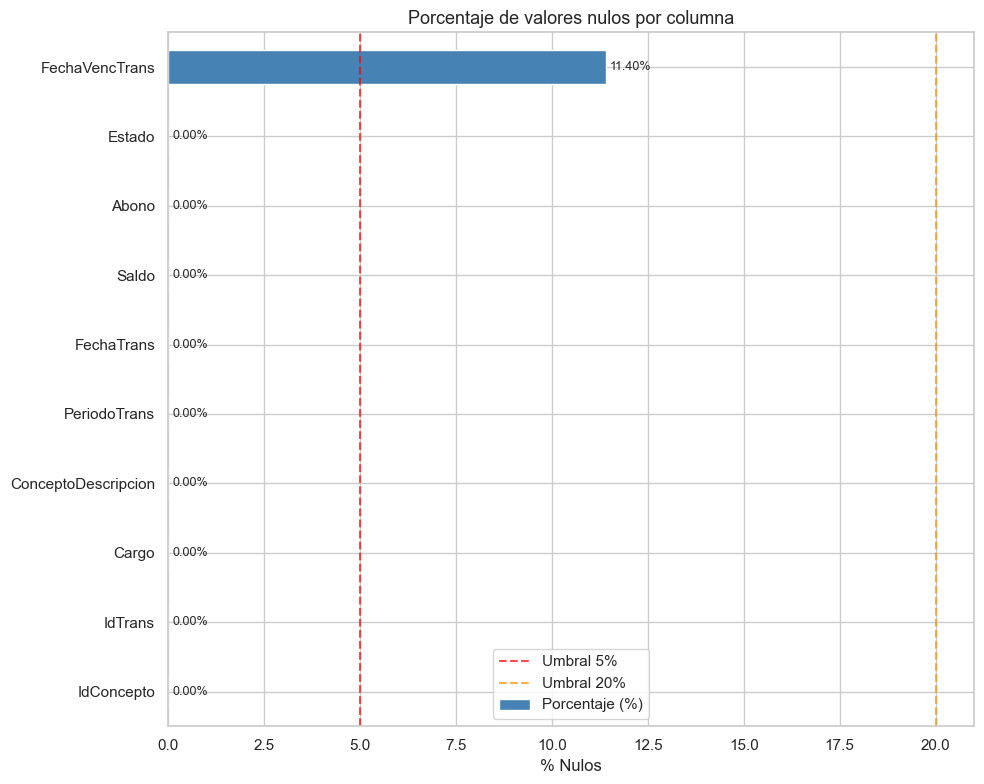


=== Conceptos con FechaVencTrans nula (Top 15) ===


ConceptoDescripcion
VENCIMIENTO DE PUNTOS DORADOS GANADOS EN MARZO DE 2021 Y NO CANJEADOS         42570
VENCIMIENTO DE PUNTOS DORADOS GANADOS EN FEBRERO DE 2021 Y NO CANJEADOS       42415
VENCIMIENTO DE PUNTOS DORADOS GANADOS EN MAYO DE 2021 Y NO CANJEADOS          42215
VENCIMIENTO DE PUNTOS DORADOS GANADOS EN DICIEMBRE DE 2020 Y NO CANJEADOS     42153
VENCIMIENTO DE PUNTOS DORADOS GANADOS EN JUNIO DE 2021 Y NO CANJEADOS         42083
VENCIMIENTO DE PUNTOS DORADOS GANADOS EN AGOSTO DE 2021 Y NO CANJEADOS        41960
VENCIMIENTO DE PUNTOS DORADOS GANADOS EN SEPTIEMBRE DE 2021 Y NO CANJEADOS    41250
VENCIMIENTO DE PUNTOS DORADOS GANADOS EN ENERO DE 2021 Y NO CANJEADOS         40722
VENCIMIENTO DE PUNTOS DORADOS GANADOS EN JULIO DE 2021 Y NO CANJEADOS         40716
VENCIMIENTO DE PUNTOS DORADOS GANADOS EN OCTUBRE DE 2021 Y NO CANJEADOS       40514
VENCIMIENTO DE PUNTOS DORADOS GANADOS EN NOVIEMBRE DE 2021 Y NO CANJEADOS     40449
VENCIMIENTO DE PUNTOS DORADOS GANADOS EN ABRIL DE 2022 Y

In [8]:
cols_con_nulos = nulos[nulos['Nulos'] > 0].index.tolist()

if cols_con_nulos:
    fig, ax = plt.subplots(figsize=(10, max(4, len(cols_con_nulos) * 0.8)))
    nulos.loc[cols_con_nulos, 'Porcentaje (%)'].sort_values().plot(
        kind='barh', ax=ax, color='steelblue', edgecolor='white'
    )
    ax.set_title('Porcentaje de valores nulos por columna', fontsize=13)
    ax.set_xlabel('% Nulos')
    ax.axvline(5, color='red', linestyle='--', alpha=0.7, label='Umbral 5%')
    ax.axvline(20, color='darkorange', linestyle='--', alpha=0.7, label='Umbral 20%')
    ax.legend()
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.2f}%',
                    (p.get_width() + 0.1, p.get_y() + p.get_height() / 2),
                    va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

    # Detalle: ¿los nulos de FechaVencTrans corresponden a algún concepto específico?
    if 'FechaVencTrans' in cols_con_nulos and 'ConceptoDescripcion' in df.columns:
        print('\n=== Conceptos con FechaVencTrans nula (Top 15) ===')
        display(df[df['FechaVencTrans'].isnull()]['ConceptoDescripcion'].value_counts().head(15))
else:
    print('No hay valores nulos en el dataset.')

## 5. Estadísticas Descriptivas

In [9]:
print('=== Variables Numéricas — Estadísticas Descriptivas ===')
df[col_numericas].describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std', '50%'])

=== Variables Numéricas — Estadísticas Descriptivas ===


,count,mean,std,min,25%,50%,75%,max
IdCtaCte,8848282.000000,120416.050247,66113.498071,3.000000,66115.000000,118610.000000,172975.000000,285470.000000
IdTrans,8848281.000000,70.957550,41.814998,1.000000,38.000000,72.000000,101.000000,241.000000
IdConcepto,8848281.000000,6.464937,9.788264,1.000000,2.000000,2.000000,4.000000,201.000000
PeriodoTrans,8848281.000000,202341.187691,100.584419,202201.000000,202212.000000,202311.000000,202409.000000,202505.000000
Cargo,8848281.000000,28.487482,79.437615,0.000000,0.000000,0.000000,0.000000,250.000000
Abono,8848281.000000,342.050684,241.236806,0.000000,250.000000,250.000000,600.000000,36900.000000
Saldo,8848281.000000,12966.723117,9133.127076,-18550.000000,6500.000000,12000.000000,14600.000000,54040.000000
Estado,8848281.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
# Estadísticas adicionales: asimetría, curtosis, ceros y negativos
stats_extra = pd.DataFrame({
    'Skewness': df[col_numericas].skew(),
    'Kurtosis': df[col_numericas].kurt(),
    'Ceros': (df[col_numericas] == 0).sum(),
    '% Ceros': ((df[col_numericas] == 0).sum() / len(df) * 100).round(2),
    'Negativos': (df[col_numericas] < 0).sum(),
    '% Negativos': ((df[col_numericas] < 0).sum() / len(df) * 100).round(2)
})
print('=== Asimetría, Curtosis, Ceros y Negativos ===')
display(stats_extra)

=== Asimetría, Curtosis, Ceros y Negativos ===


,Skewness,Kurtosis,Ceros,% Ceros,Negativos,% Negativos
IdCtaCte,0.1482,-0.9133,0,0.0000,0,0.0000
IdTrans,0.1591,-0.6898,0,0.0000,0,0.0000
IdConcepto,2.2473,3.5029,0,0.0000,0,0.0000
PeriodoTrans,0.0507,-1.1565,0,0.0000,0,0.0000
Cargo,2.4299,3.9044,7840020,88.6000,0,0.0000
Abono,2.8900,235.7314,1008261,11.3900,0,0.0000
Saldo,1.0291,0.4045,102615,1.1600,170,0.0000
Estado,0.0000,0.0000,0,0.0000,0,0.0000


## 6. Análisis de Variables Categóricas

In [11]:
# Cardinalidad de variables categóricas
cat_info = []
for c in col_categoricas:
    vc = df[c].value_counts()
    cat_info.append({
        'Columna': c,
        'Valores únicos': df[c].nunique(),
        'Valor más frecuente': vc.index[0] if len(vc) > 0 else 'N/A',
        'Frecuencia moda': vc.iloc[0] if len(vc) > 0 else 0,
        '% Moda': round(vc.iloc[0] / len(df) * 100, 2) if len(vc) > 0 else 0
    })

cardinalidad = pd.DataFrame(cat_info).set_index('Columna').sort_values('Valores únicos', ascending=False)
print('=== Cardinalidad de Variables Categóricas ===')
display(cardinalidad)

=== Cardinalidad de Variables Categóricas ===


,Valores únicos,Valor más frecuente,Frecuencia moda,% Moda
Columna,,,,
ConceptoDescripcion,256,PUNTOS DORADOS POR CUMPLEAÑOS COMO MIEMBRO EN CLUB AÑOS DORADOS,376565,4.2600


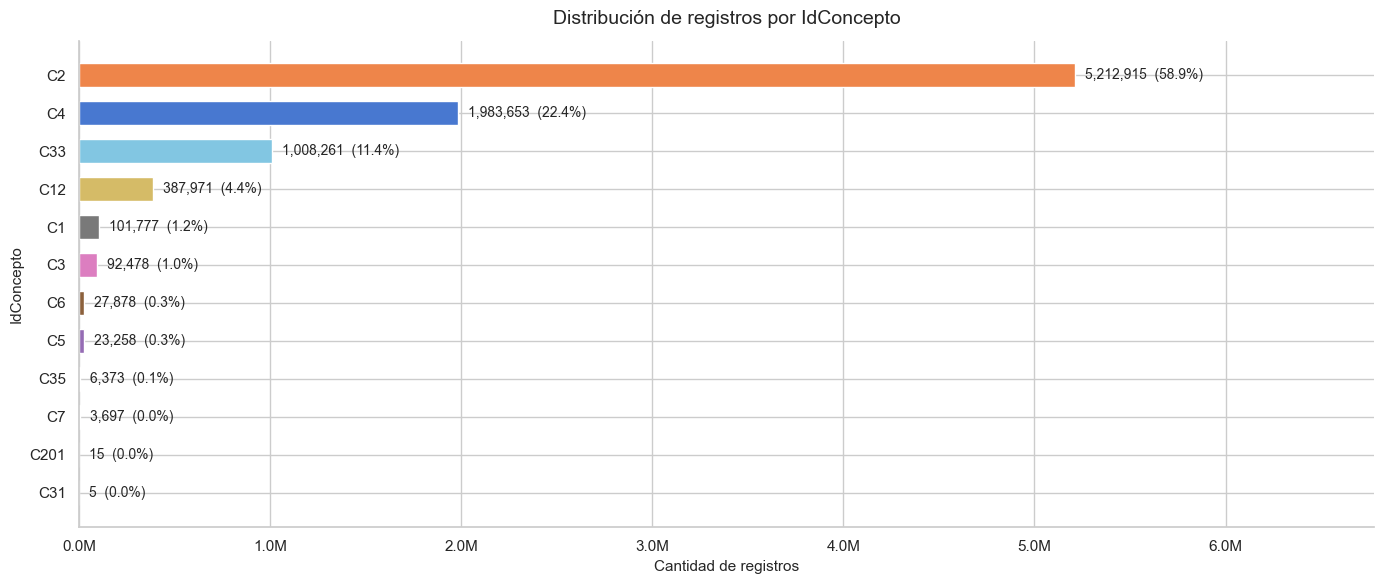


=== Descripción representativa por IdConcepto ===
  [C  1]   1.2%  (  101,777 registros)  PUNTOS POR INCORPORACION AL...
  [C  2]  58.9%  (5,212,915 registros)  PUNTOS DORADOS POR MANTENCION...
  [C  3]   1.0%  (   92,478 registros)  PUNTOS DORADOS POR COMPRAS...
  [C  4]  22.4%  (1,983,653 registros)  PUNTOS DORADOS POR PAGO...
  [C  5]   0.3%  (   23,258 registros)  PUNTOS DORADOS POR INGRESO...
  [C  6]   0.3%  (   27,878 registros)  PUNTOS DORADOS POR USO...
  [C  7]   0.0%  (    3,697 registros)  PUNTOS DORADOS POR INGRESO...
  [C 12]   4.4%  (  387,971 registros)  PUNTOS DORADOS POR CUMPLEAÑOS...
  [C 31]   0.0%  (        5 registros)  ANULACION CANJE PUNTOS DORADOS...
  [C 33]  11.4%  (1,008,261 registros)  VENCIMIENTO DE PUNTOS DORADOS...
  [C 35]   0.1%  (    6,373 registros)  PUNTOS DORADOS POR INGRESO...
  [C201]   0.0%  (       15 registros)  REVERSO DE CANJE...


In [12]:
# Distribución de IdConcepto (baja cardinalidad — concepto de negocio clave)
if 'IdConcepto' in df.columns:
    # Descripción corta (primeras 4 palabras) por concepto
    concepto_map = df.dropna(subset=['IdConcepto', 'ConceptoDescripcion']) \
                     .groupby('IdConcepto')['ConceptoDescripcion'] \
                     .agg(lambda x: x.str.split().str[:4].str.join(' ').mode()[0] if len(x) > 0 else '') \
                     .to_dict()

    freq_concepto = df['IdConcepto'].value_counts().sort_values(ascending=True)
    total         = freq_concepto.sum()
    labels_int    = [f'C{int(k)}' for k in freq_concepto.index]
    pcts          = (freq_concepto / total * 100).values

    fig, ax = plt.subplots(figsize=(14, 6))
    colores = sns.color_palette('muted', len(freq_concepto))

    barras = ax.barh(labels_int, freq_concepto.values,
                     color=colores, edgecolor='white', height=0.65)

    # Etiqueta: cantidad + porcentaje al final de cada barra
    for bar, val, pct in zip(barras, freq_concepto.values, pcts):
        etiqueta = f'{val:,.0f}  ({pct:.1f}%)'
        x_pos    = bar.get_width() + freq_concepto.max() * 0.01
        ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                etiqueta, va='center', fontsize=10)

    ax.set_title('Distribución de registros por IdConcepto', fontsize=14, pad=12)
    ax.set_xlabel('Cantidad de registros', fontsize=11)
    ax.set_ylabel('IdConcepto', fontsize=11)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.set_xlim(0, freq_concepto.max() * 1.30)
    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    plt.show()

    print('\n=== Descripción representativa por IdConcepto ===')
    for k, v in sorted(concepto_map.items()):
        n   = df['IdConcepto'].value_counts().get(k, 0)
        pct = n / total * 100
        print(f'  [C{int(k):>3}] {pct:5.1f}%  ({n:>9,} registros)  {v}...')

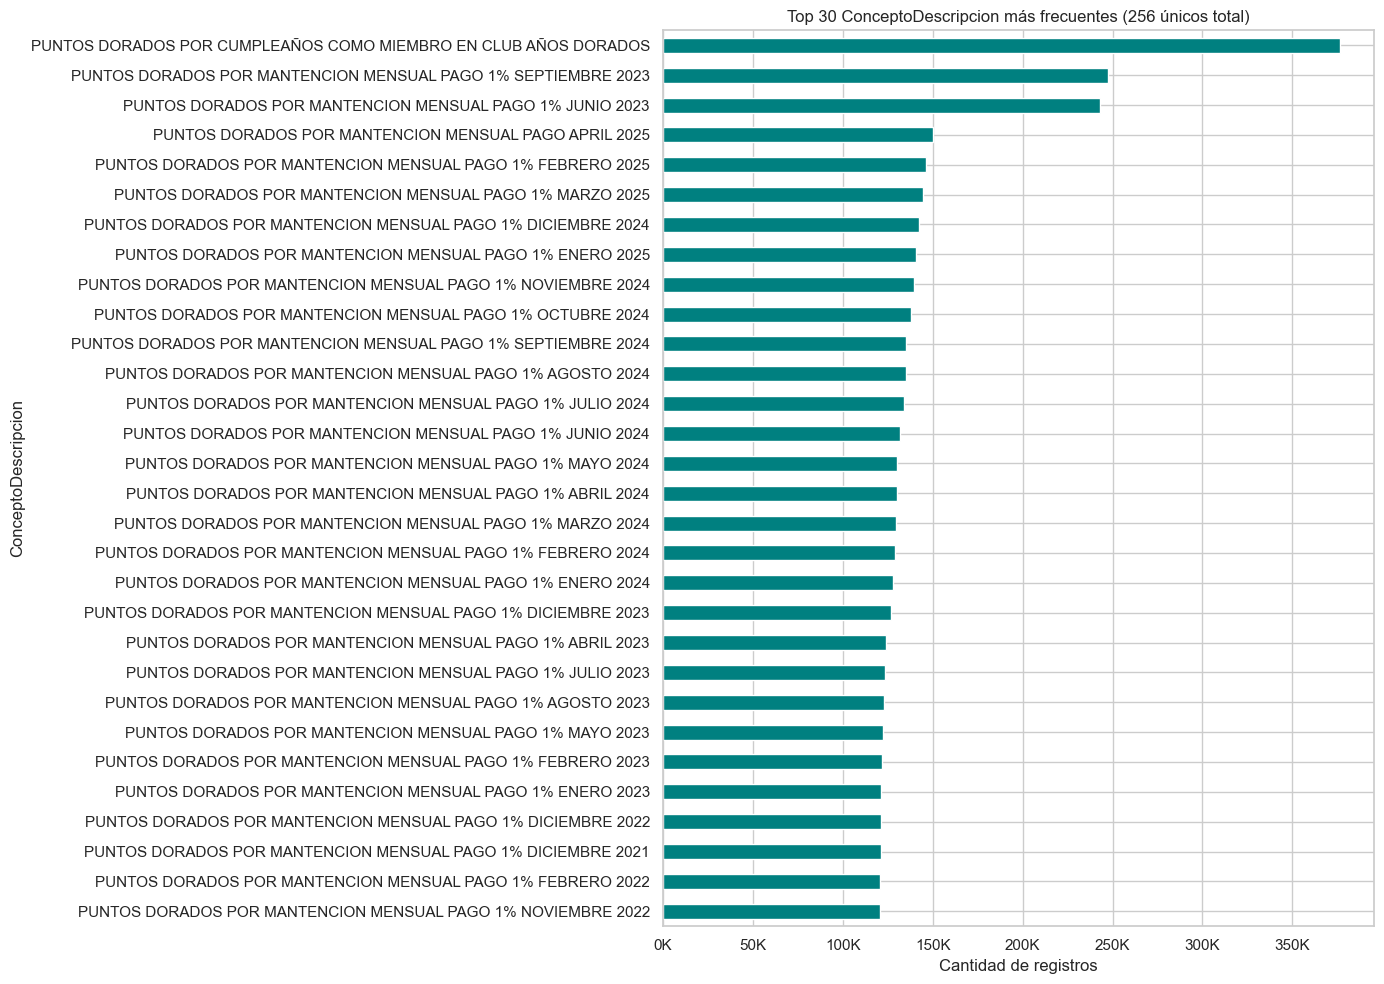

In [13]:
# Top 30 ConceptoDescripcion más frecuentes
if 'ConceptoDescripcion' in df.columns:
    top_concepto = df['ConceptoDescripcion'].value_counts().head(30)

    fig, ax = plt.subplots(figsize=(14, 10))
    top_concepto.sort_values().plot(kind='barh', ax=ax, color='teal', edgecolor='white')
    ax.set_title(f'Top 30 ConceptoDescripcion más frecuentes ({df["ConceptoDescripcion"].nunique()} únicos total)', fontsize=12)
    ax.set_xlabel('Cantidad de registros')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    plt.tight_layout()
    plt.show()

=== Distribución de Estado ===


,Frecuencia,% Total
Estado,,
1.0000,8848281,100.0000
NaN,1,0.0000


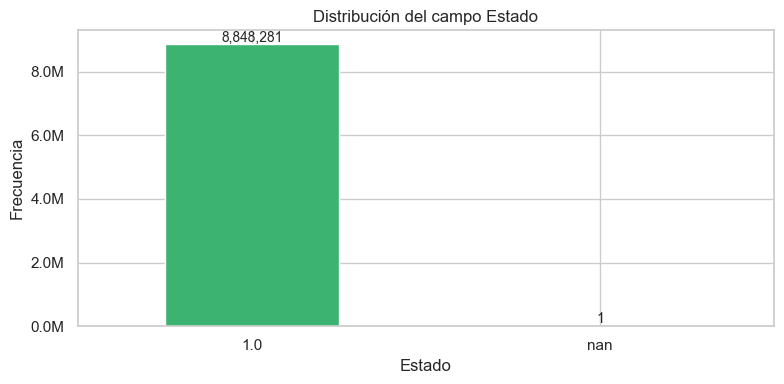

In [14]:
# Distribución del campo Estado
if 'Estado' in df.columns:
    estado_counts = df['Estado'].value_counts(dropna=False)
    print('=== Distribución de Estado ===')
    display(estado_counts.to_frame('Frecuencia').assign(**{'% Total': lambda x: (x['Frecuencia'] / len(df) * 100).round(2)}))

    fig, ax = plt.subplots(figsize=(8, 4))
    estado_counts.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
    ax.set_title('Distribución del campo Estado')
    ax.set_xlabel('Estado')
    ax.set_ylabel('Frecuencia')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 7. Análisis de Variables Numéricas — Distribuciones (Cargo, Abono, Saldo)

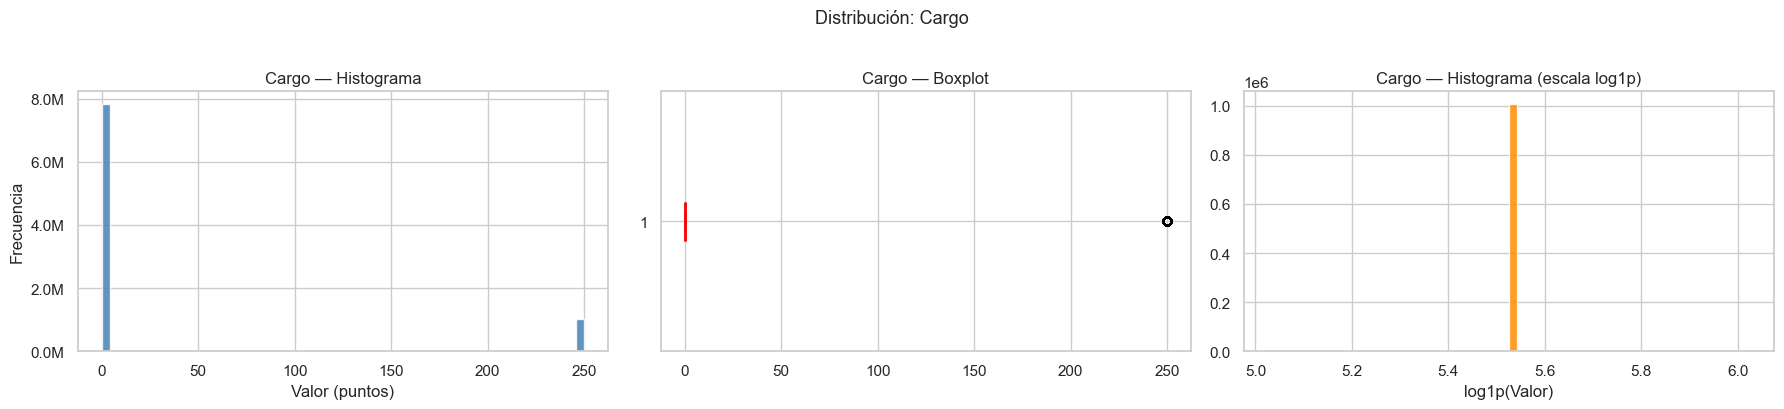

--- Estadísticas: Cargo ---
count   8,848,281.0000
mean           28.4875
std            79.4376
min             0.0000
25%             0.0000
50%             0.0000
75%             0.0000
max           250.0000
Ceros: 7,840,020 (88.61%)
Negativos: 0 (0.0000%)



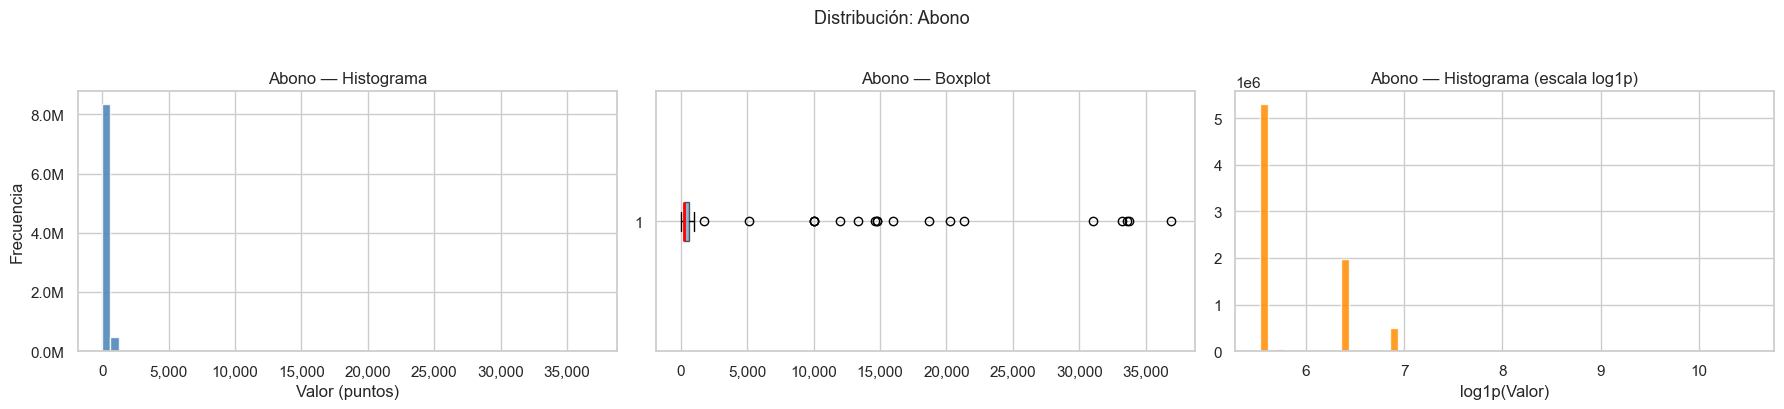

--- Estadísticas: Abono ---
count   8,848,281.0000
mean          342.0507
std           241.2368
min             0.0000
25%           250.0000
50%           250.0000
75%           600.0000
max        36,900.0000
Ceros: 1,008,261 (11.39%)
Negativos: 0 (0.0000%)



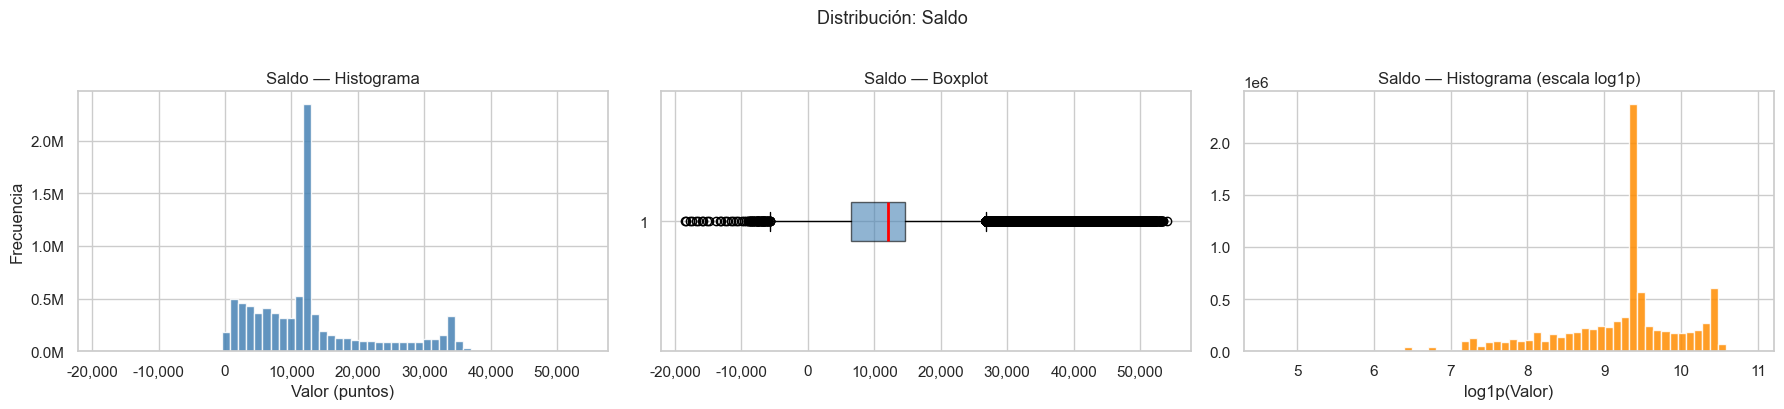

--- Estadísticas: Saldo ---
count   8,848,281.0000
mean       12,966.7231
std         9,133.1271
min       -18,550.0000
25%         6,500.0000
50%        12,000.0000
75%        14,600.0000
max        54,040.0000
Ceros: 102,615 (1.16%)
Negativos: 170 (0.0019%)



In [15]:
cols_montos = [c for c in ['Cargo', 'Abono', 'Saldo'] if c in df.columns]

for col in cols_montos:
    datos = df[col].dropna()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Histograma
    axes[0].hist(datos, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].set_title(f'{col} — Histograma')
    axes[0].set_xlabel('Valor (puntos)')
    axes[0].set_ylabel('Frecuencia')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

    # Boxplot
    axes[1].boxplot(datos, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_title(f'{col} — Boxplot')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # Log-escala (solo valores positivos)
    datos_pos = datos[datos > 0]
    if len(datos_pos) > 0:
        axes[2].hist(np.log1p(datos_pos), bins=60, color='darkorange', edgecolor='white', alpha=0.85)
        axes[2].set_title(f'{col} — Histograma (escala log1p)')
        axes[2].set_xlabel('log1p(Valor)')

    plt.suptitle(f'Distribución: {col}', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'--- Estadísticas: {col} ---')
    print(datos.describe().to_string())
    print(f'Ceros: {(datos == 0).sum():,} ({(datos == 0).sum()/len(datos)*100:.2f}%)')
    print(f'Negativos: {(datos < 0).sum():,} ({(datos < 0).sum()/len(datos)*100:.4f}%)')
    print()

In [16]:
# Análisis de registros con Saldo negativo
if 'Saldo' in df.columns:
    df_neg = df[df['Saldo'] < 0]
    print(f'Registros con Saldo negativo: {len(df_neg):,} ({len(df_neg)/len(df)*100:.4f}%)')

    if len(df_neg) > 0:
        print('\n=== Conceptos con Saldo negativo ===')
        display(df_neg['ConceptoDescripcion'].value_counts().head(10))

        print('\n=== Estadísticas del Saldo negativo ===')
        print(df_neg['Saldo'].describe().to_string())

Registros con Saldo negativo: 170 (0.0019%)

=== Conceptos con Saldo negativo ===


ConceptoDescripcion
PUNTOS DORADOS POR CUMPLEAÑOS COMO MIEMBRO EN CLUB AÑOS DORADOS    9
PUNTOS DORADOS POR MANTENCION MENSUAL PAGO 1% JUNIO 2023           7
PUNTOS DORADOS POR MANTENCION MENSUAL PAGO 1% FEBRERO 2024         6
PUNTOS DORADOS POR MANTENCION MENSUAL PAGO 1% JULIO 2024           5
PUNTOS DORADOS POR MANTENCION MENSUAL PAGO 1% MARZO 2024           5
PUNTOS DORADOS POR MANTENCION MENSUAL PAGO 1% JUNIO 2024           5
PUNTOS DORADOS POR MANTENCION MENSUAL PAGO 1% MAYO 2024            5
PUNTOS DORADOS POR MANTENCION MENSUAL PAGO 1% ABRIL 2024           5
PUNTOS DORADOS POR PAGO OPORTUNO CREDITO SOCIAL FEBRERO 2024       5
PUNTOS DORADOS POR MANTENCION MENSUAL PAGO 1% DICIEMBRE 2022       4
Name: count, dtype: int64


=== Estadísticas del Saldo negativo ===
count       170.0000
mean     -5,870.5882
std       4,043.6252
min     -18,550.0000
25%      -7,687.5000
50%      -5,450.0000
75%      -2,762.5000
max        -150.0000


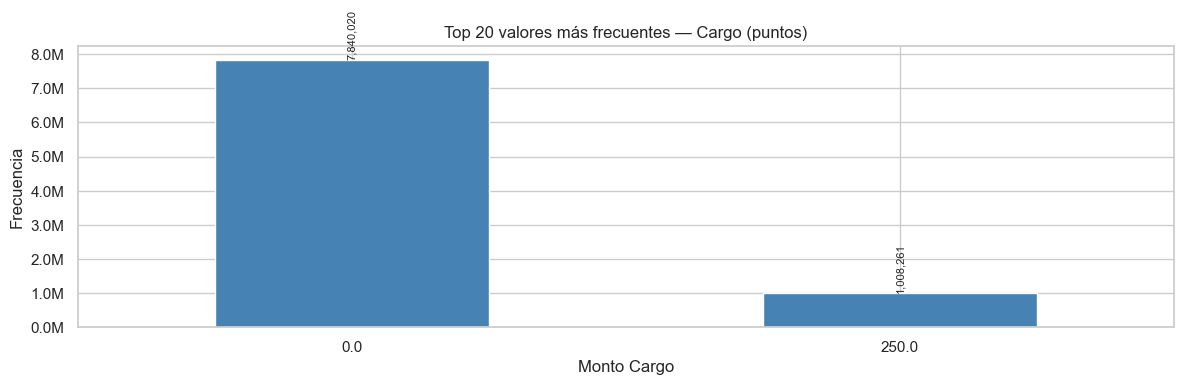

Cargo = 0: 7,840,020 registros (88.60%)



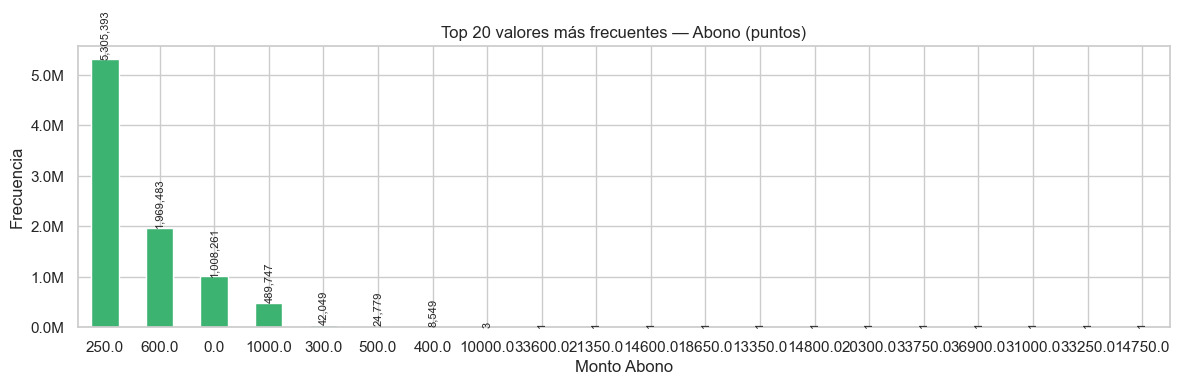

Abono = 0: 1,008,261 registros (11.39%)



In [17]:
# Distribución de valores únicos de Cargo y Abono
for col in ['Cargo', 'Abono']:
    if col in df.columns:
        vc = df[col].value_counts().head(20)
        fig, ax = plt.subplots(figsize=(12, 4))
        vc.plot(kind='bar', ax=ax, color='steelblue' if col == 'Cargo' else 'mediumseagreen', edgecolor='white')
        ax.set_title(f'Top 20 valores más frecuentes — {col} (puntos)', fontsize=12)
        ax.set_xlabel(f'Monto {col}')
        ax.set_ylabel('Frecuencia')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height()):,}',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=8, rotation=90)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

        n_cero = (df[col] == 0).sum()
        print(f'{col} = 0: {n_cero:,} registros ({n_cero/len(df)*100:.2f}%)')
        print()

## 8. Análisis Temporal

In [18]:
# Cobertura temporal del dataset
for col_fecha in col_fechas:
    datos_fecha = df[col_fecha].dropna()
    print(f'{col_fecha}:')
    print(f'  Nulos  : {df[col_fecha].isnull().sum():,} ({df[col_fecha].isnull().sum()/len(df)*100:.2f}%)')
    print(f'  Mínimo : {datos_fecha.min()}')
    print(f'  Máximo : {datos_fecha.max()}')
    print(f'  Rango  : {(datos_fecha.max() - datos_fecha.min()).days} días')
    print()

FechaTrans:
  Nulos  : 1 (0.00%)
  Mínimo : 2022-01-11 00:00:00
  Máximo : 2025-05-23 00:00:00
  Rango  : 1228 días

FechaVencTrans:
  Nulos  : 1,008,270 (11.40%)
  Mínimo : 2024-09-13 00:00:00
  Máximo : 2028-05-23 00:00:00
  Rango  : 1348 días



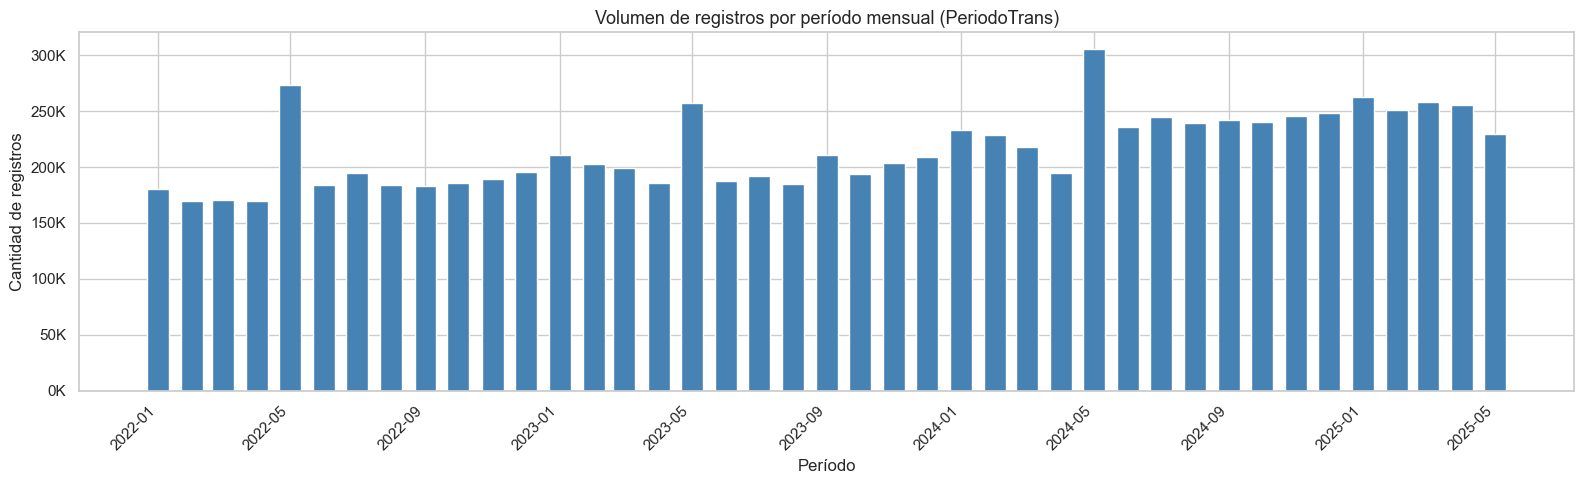

=== Volumen mensual de registros ===
FECHA_PERIODO  Registros
   2022-01-01     180395
   2022-02-01     169611
   2022-03-01     170708
   2022-04-01     169211
   2022-05-01     273252
   2022-06-01     183961
   2022-07-01     194503
   2022-08-01     183630
   2022-09-01     182891
   2022-10-01     185616
   2022-11-01     189550
   2022-12-01     195350
   2023-01-01     210654
   2023-02-01     202977
   2023-03-01     198814
   2023-04-01     185885
   2023-05-01     257074
   2023-06-01     187460
   2023-07-01     192275
   2023-08-01     185235
   2023-09-01     210674
   2023-10-01     193965
   2023-11-01     203362
   2023-12-01     208762
   2024-01-01     233187
   2024-02-01     228220
   2024-03-01     217620
   2024-04-01     194650
   2024-05-01     305125
   2024-06-01     235377
   2024-07-01     244936
   2024-08-01     239666
   2024-09-01     241736
   2024-10-01     240450
   2024-11-01     246033
   2024-12-01     248681
   2025-01-01     262478
   2025-02-01

In [19]:
# Volumen mensual de registros por PeriodoTrans
if 'PeriodoTrans' in df.columns:
    df_periodo = df.dropna(subset=['PeriodoTrans']).copy()
    df_periodo['FECHA_PERIODO'] = pd.to_datetime(
        df_periodo['PeriodoTrans'].astype(int).astype(str), format='%Y%m'
    )

    vol_mensual = df_periodo.groupby('FECHA_PERIODO').size().reset_index(name='Registros')

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.bar(vol_mensual['FECHA_PERIODO'], vol_mensual['Registros'], color='steelblue', width=20)
    ax.set_title('Volumen de registros por período mensual (PeriodoTrans)', fontsize=13)
    ax.set_xlabel('Período')
    ax.set_ylabel('Cantidad de registros')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print('=== Volumen mensual de registros ===')
    print(vol_mensual.sort_values('FECHA_PERIODO').to_string(index=False))

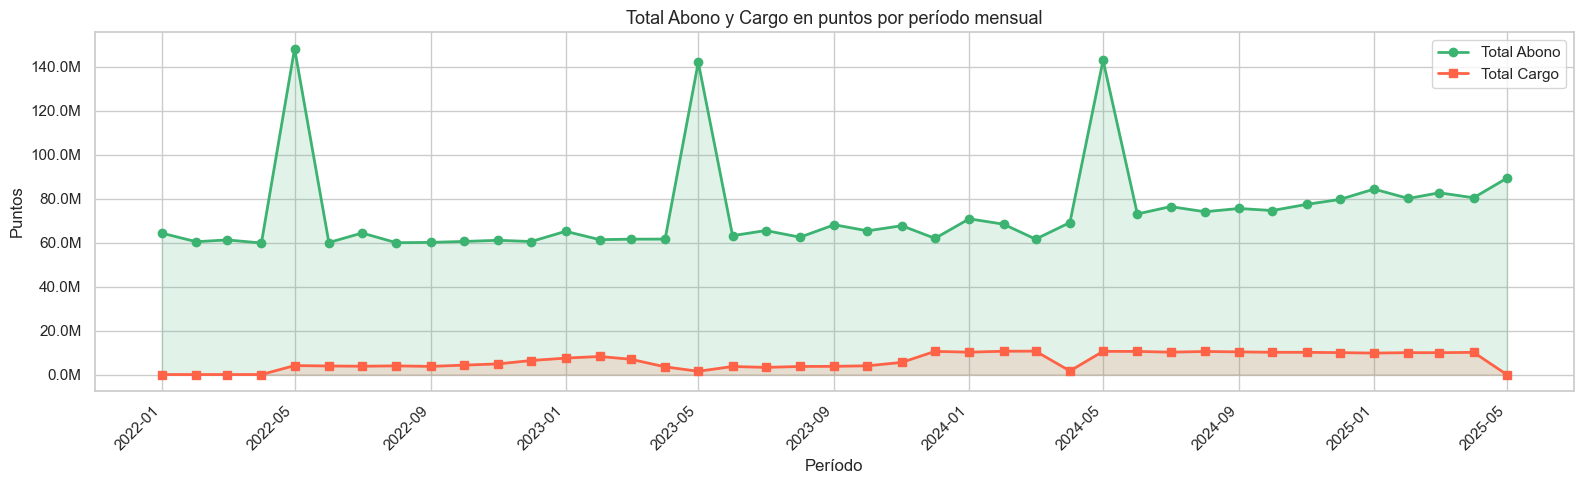

In [20]:
# Abono y Cargo total mensual
if 'FECHA_PERIODO' in df_periodo.columns:
    montos_mes = df_periodo.groupby('FECHA_PERIODO').agg(
        Total_Abono=('Abono', 'sum'),
        Total_Cargo=('Cargo', 'sum')
    ).reset_index()

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(montos_mes['FECHA_PERIODO'], montos_mes['Total_Abono'],
            marker='o', color='mediumseagreen', linewidth=2, label='Total Abono')
    ax.plot(montos_mes['FECHA_PERIODO'], montos_mes['Total_Cargo'],
            marker='s', color='tomato', linewidth=2, label='Total Cargo')
    ax.fill_between(montos_mes['FECHA_PERIODO'], montos_mes['Total_Abono'], alpha=0.15, color='mediumseagreen')
    ax.fill_between(montos_mes['FECHA_PERIODO'], montos_mes['Total_Cargo'], alpha=0.15, color='tomato')
    ax.set_title('Total Abono y Cargo en puntos por período mensual', fontsize=13)
    ax.set_xlabel('Período')
    ax.set_ylabel('Puntos')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.legend(fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

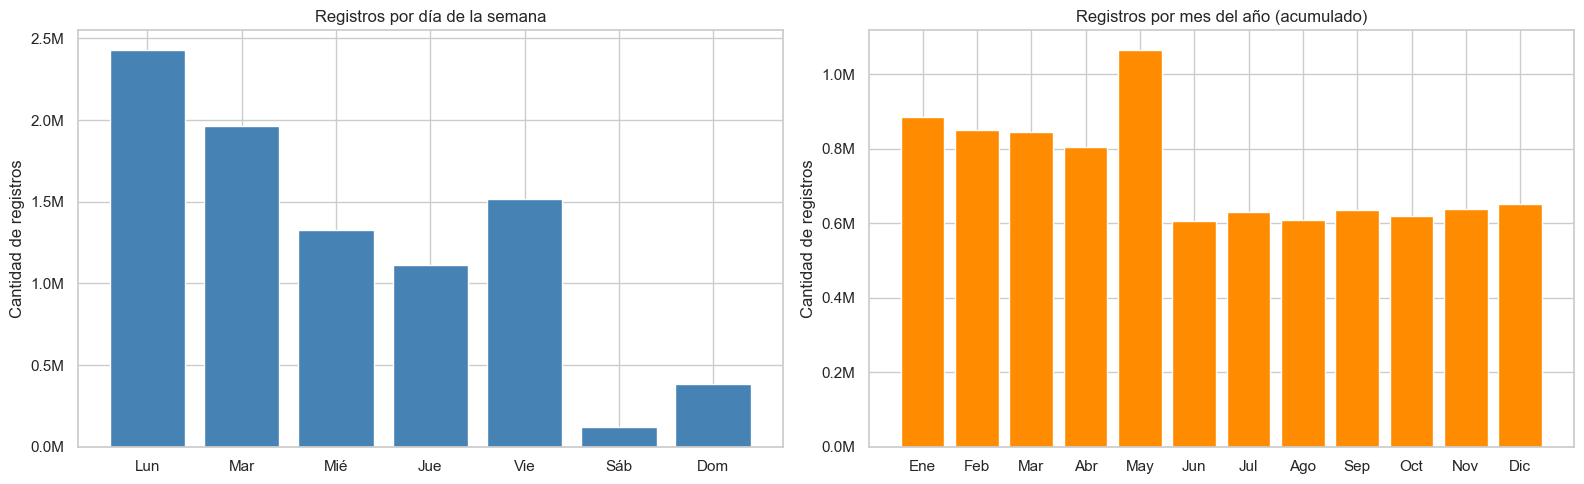

In [21]:
# Distribución por día de la semana y mes del año
if 'FechaTrans' in df.columns:
    df_fecha = df.dropna(subset=['FechaTrans']).copy()
    df_fecha['DiaSemana'] = df_fecha['FechaTrans'].dt.day_name(locale='es_CL' if pd.Timestamp.now() else None)
    df_fecha['MesAnio']   = df_fecha['FechaTrans'].dt.month
    df_fecha['Anio']      = df_fecha['FechaTrans'].dt.year

    orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dias_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
    dia_semana_counts = df_fecha['FechaTrans'].dt.day_of_week.value_counts().sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].bar(dias_labels, [dia_semana_counts.get(i, 0) for i in range(7)],
                color='steelblue', edgecolor='white')
    axes[0].set_title('Registros por día de la semana')
    axes[0].set_ylabel('Cantidad de registros')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

    mes_counts = df_fecha['MesAnio'].value_counts().sort_index()
    meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    axes[1].bar([meses[m-1] for m in mes_counts.index], mes_counts.values,
                color='darkorange', edgecolor='white')
    axes[1].set_title('Registros por mes del año (acumulado)')
    axes[1].set_ylabel('Cantidad de registros')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

    plt.tight_layout()
    plt.show()

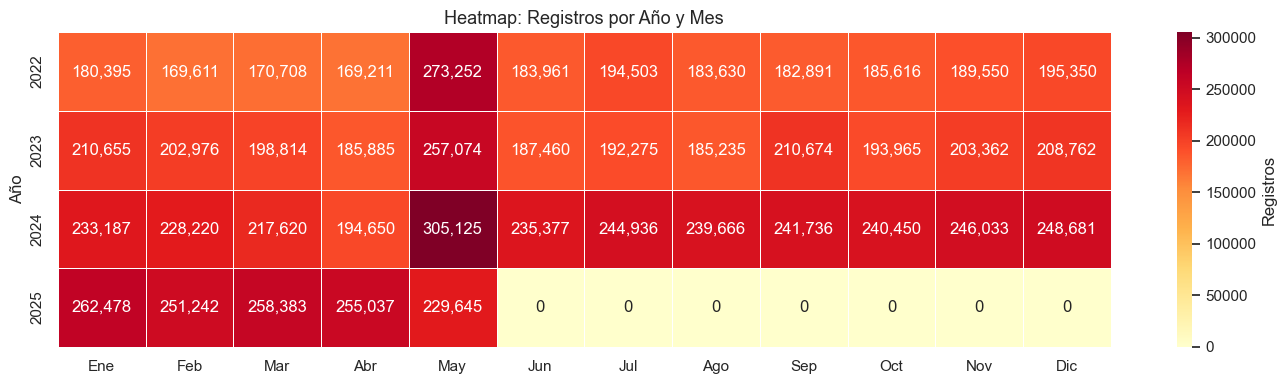

In [22]:
# Heatmap: registros por año y mes
if 'FechaTrans' in df.columns:
    df_fecha_hm = df.dropna(subset=['FechaTrans']).copy()
    df_fecha_hm['Anio'] = df_fecha_hm['FechaTrans'].dt.year
    df_fecha_hm['Mes']  = df_fecha_hm['FechaTrans'].dt.month

    pivot = df_fecha_hm.groupby(['Anio', 'Mes']).size().unstack(fill_value=0)
    pivot.columns = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                     'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'][:pivot.shape[1]]

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(pivot, annot=True, fmt=',d', cmap='YlOrRd', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Registros'})
    ax.set_title('Heatmap: Registros por Año y Mes', fontsize=13)
    ax.set_ylabel('Año')
    plt.tight_layout()
    plt.show()

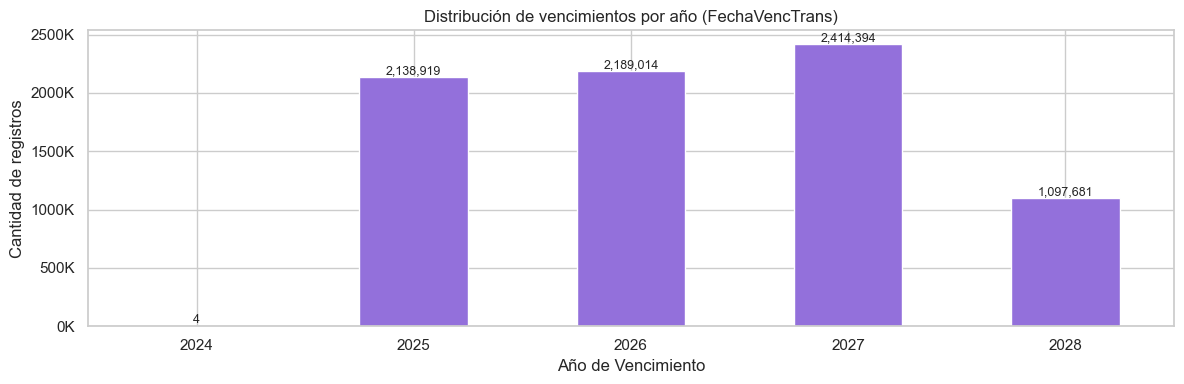

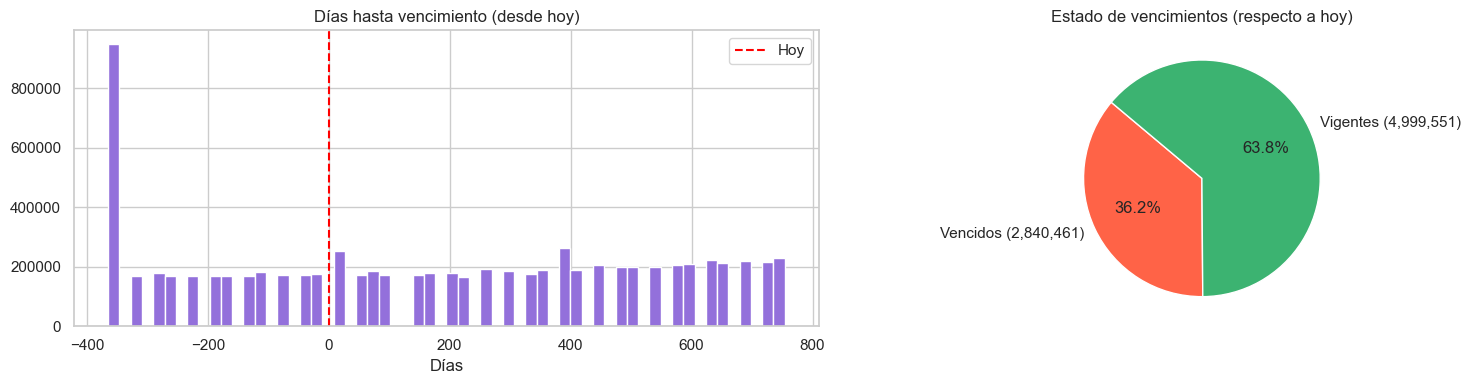

Registros con FechaVencTrans en el pasado (vencidos): 2,840,461 (36.23%)
Registros con FechaVencTrans en el futuro (vigentes): 4,999,551 (63.77%)


In [23]:
# Análisis de FechaVencTrans: distribución de vencimientos
if 'FechaVencTrans' in df.columns:
    df_venc = df.dropna(subset=['FechaVencTrans']).copy()
    df_venc['Anio_Venc'] = df_venc['FechaVencTrans'].dt.year
    df_venc['Mes_Venc']  = df_venc['FechaVencTrans'].dt.month

    venc_anio = df_venc['Anio_Venc'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 4))
    venc_anio.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
    ax.set_title('Distribución de vencimientos por año (FechaVencTrans)', fontsize=12)
    ax.set_xlabel('Año de Vencimiento')
    ax.set_ylabel('Cantidad de registros')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Días hasta vencimiento
    FECHA_REF = pd.Timestamp('today').normalize()
    df_venc['Dias_Hasta_Venc'] = (df_venc['FechaVencTrans'] - FECHA_REF).dt.days

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    df_venc['Dias_Hasta_Venc'].clip(-365, 1460).hist(
        bins=60, ax=axes[0], color='mediumpurple', edgecolor='white'
    )
    axes[0].axvline(0, color='red', linestyle='--', label='Hoy')
    axes[0].set_title('Días hasta vencimiento (desde hoy)')
    axes[0].set_xlabel('Días')
    axes[0].legend()

    vencidos = (df_venc['Dias_Hasta_Venc'] < 0).sum()
    vigentes  = (df_venc['Dias_Hasta_Venc'] >= 0).sum()
    axes[1].pie(
        [vencidos, vigentes],
        labels=[f'Vencidos ({vencidos:,})', f'Vigentes ({vigentes:,})'],
        autopct='%1.1f%%',
        colors=['tomato', 'mediumseagreen'],
        startangle=140
    )
    axes[1].set_title('Estado de vencimientos (respecto a hoy)')

    plt.tight_layout()
    plt.show()

    print(f'Registros con FechaVencTrans en el pasado (vencidos): {vencidos:,} ({vencidos/len(df_venc)*100:.2f}%)')
    print(f'Registros con FechaVencTrans en el futuro (vigentes): {vigentes:,} ({vigentes/len(df_venc)*100:.2f}%)')

## 9. Análisis por Variables de Negocio Clave

=== Estadísticas por IdConcepto ===


,Registros,Abono_Promedio,Abono_Total,Cargo_Promedio,Cargo_Total,Saldo_Promedio,Saldo_Mediana
IdConcepto,,,,,,,
2.000000,"5,212,915.00",250.00,"1,303,228,750.00",0.00,0.00,"12,207.68","12,000.00"
4.000000,"1,983,653.00",597.86,"1,185,940,800.00",0.00,0.00,"15,401.18","12,050.00"
33.000000,"1,008,261.00",0.00,0.00,250.00,"252,065,250.00","13,326.49","12,000.00"
12.000000,"387,971.00","1,000.03","387,982,000.00",0.00,0.00,"13,818.62","12,250.00"
1.000000,"101,777.00","1,000.00","101,777,000.00",0.00,0.00,0.25,0.00
3.000000,"92,478.00",250.00,"23,119,500.00",0.00,0.00,"11,298.98","9,250.00"
6.000000,"27,878.00",300.00,"8,363,400.00",0.00,0.00,"8,070.71","6,550.00"
5.000000,"23,258.00",500.00,"11,629,000.00",0.00,0.00,"15,186.50","12,050.00"
35.000000,"6,373.00",400.00,"2,549,200.00",0.00,0.00,"11,730.10","9,050.00"


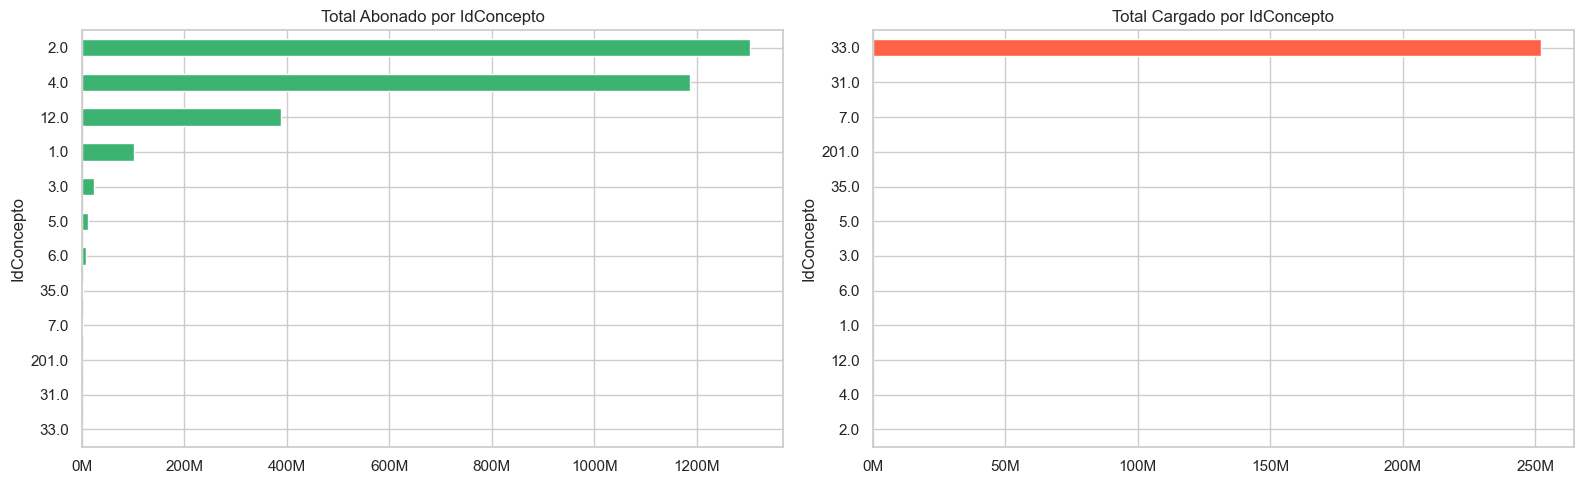

In [24]:
# Cargo, Abono y Saldo promedio por IdConcepto
if 'IdConcepto' in df.columns:
    stats_concepto = df.groupby('IdConcepto').agg(
        Registros=('IdCtaCte', 'count'),
        Abono_Promedio=('Abono', 'mean'),
        Abono_Total=('Abono', 'sum'),
        Cargo_Promedio=('Cargo', 'mean'),
        Cargo_Total=('Cargo', 'sum'),
        Saldo_Promedio=('Saldo', 'mean'),
        Saldo_Mediana=('Saldo', 'median')
    ).sort_values('Registros', ascending=False)

    print('=== Estadísticas por IdConcepto ===')
    display(stats_concepto.style.format('{:,.2f}').background_gradient(cmap='Blues', subset=['Registros']))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    stats_concepto['Abono_Total'].sort_values().plot(
        kind='barh', ax=axes[0], color='mediumseagreen', edgecolor='white'
    )
    axes[0].set_title('Total Abonado por IdConcepto')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

    stats_concepto['Cargo_Total'].sort_values().plot(
        kind='barh', ax=axes[1], color='tomato', edgecolor='white'
    )
    axes[1].set_title('Total Cargado por IdConcepto')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

    plt.tight_layout()
    plt.show()

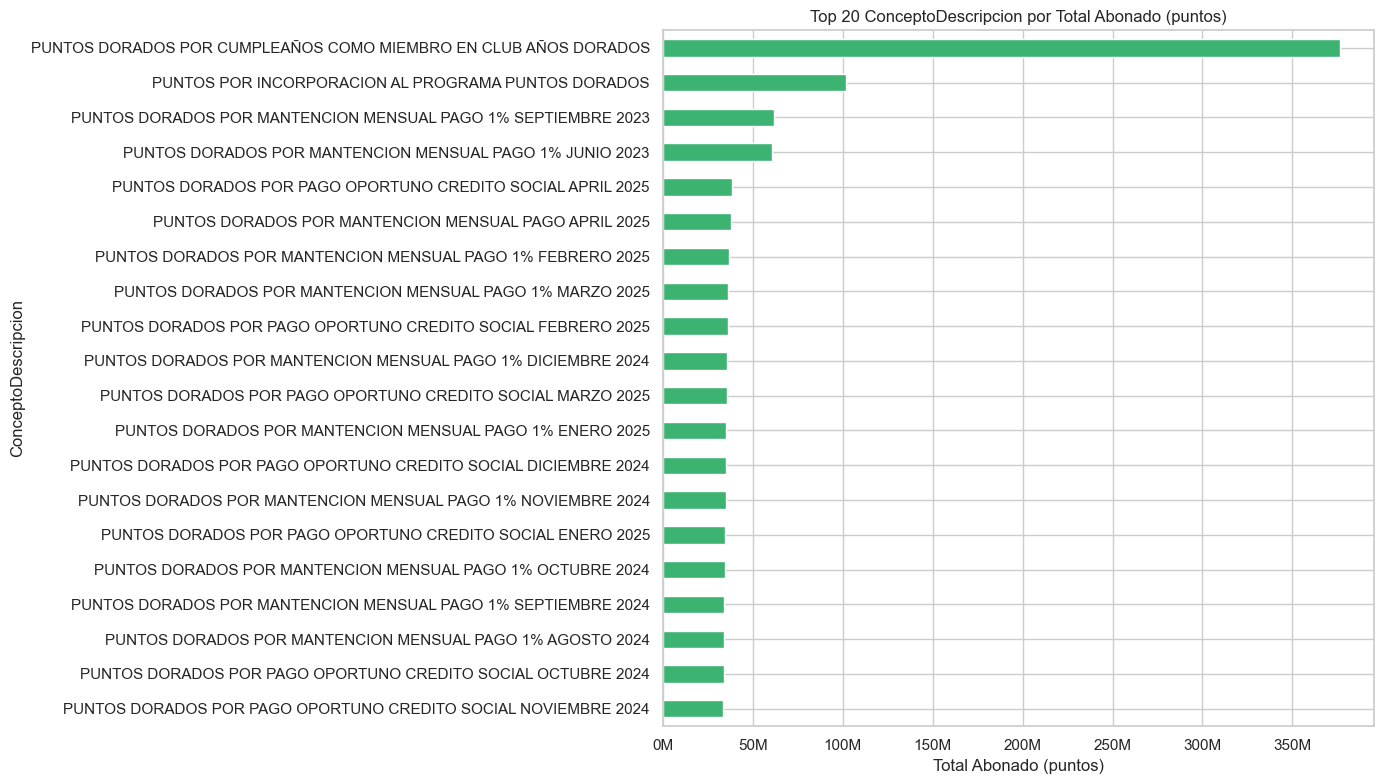

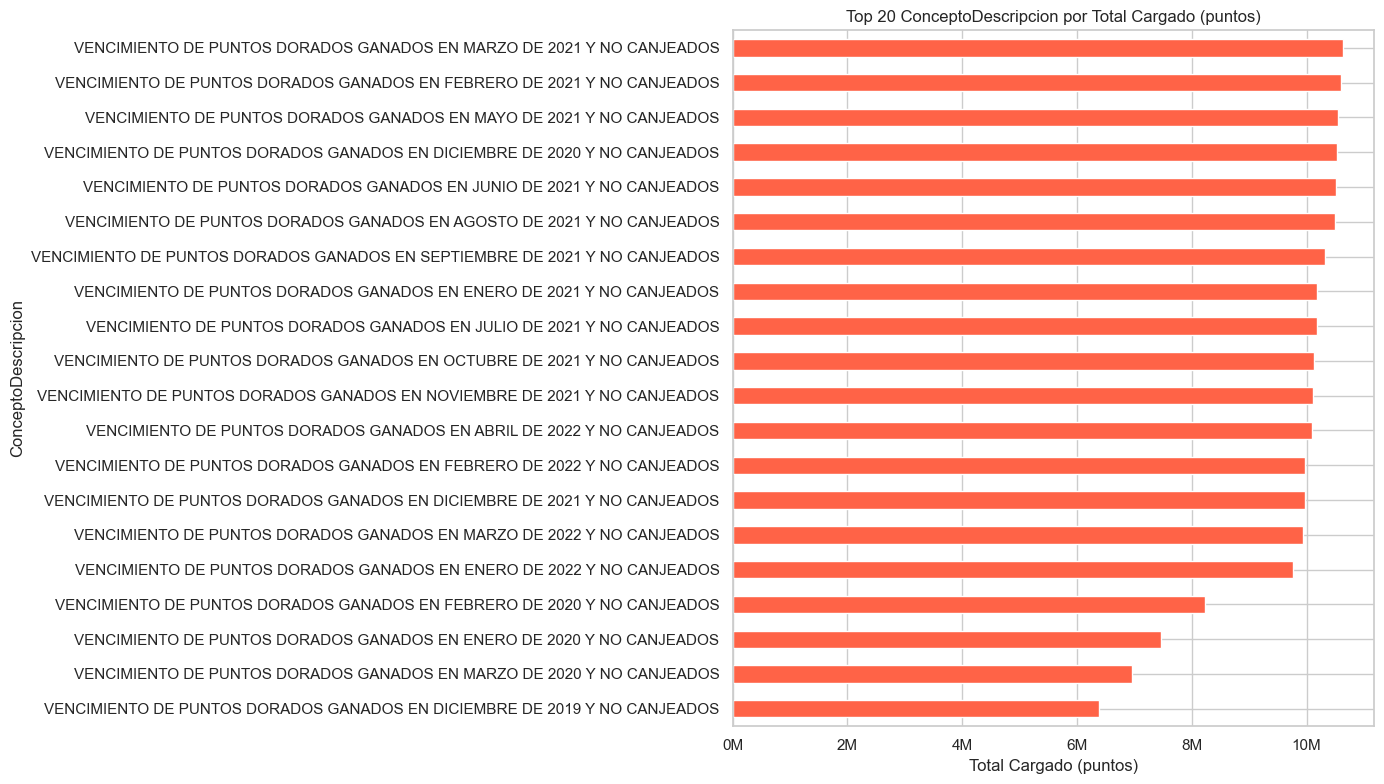

In [25]:
# Top 20 ConceptoDescripcion por monto total abonado
if 'ConceptoDescripcion' in df.columns and 'Abono' in df.columns:
    top_desc_abono = df.groupby('ConceptoDescripcion')['Abono'].sum().sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(14, 8))
    top_desc_abono.sort_values().plot(kind='barh', ax=ax, color='mediumseagreen', edgecolor='white')
    ax.set_title('Top 20 ConceptoDescripcion por Total Abonado (puntos)', fontsize=12)
    ax.set_xlabel('Total Abonado (puntos)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    plt.tight_layout()
    plt.show()

    top_desc_cargo = df.groupby('ConceptoDescripcion')['Cargo'].sum().sort_values(ascending=False).head(20)

    if top_desc_cargo.sum() > 0:
        fig, ax = plt.subplots(figsize=(14, 8))
        top_desc_cargo.sort_values().plot(kind='barh', ax=ax, color='tomato', edgecolor='white')
        ax.set_title('Top 20 ConceptoDescripcion por Total Cargado (puntos)', fontsize=12)
        ax.set_xlabel('Total Cargado (puntos)')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
        plt.tight_layout()
        plt.show()
    else:
        print('No hay cargos (Cargo > 0) en ningún ConceptoDescripcion.')

## 10. Análisis por Cuenta (IdCtaCte)

Cuentas corrientes únicas (IdCtaCte): 228,563
Promedio de registros por cuenta    : 38.71


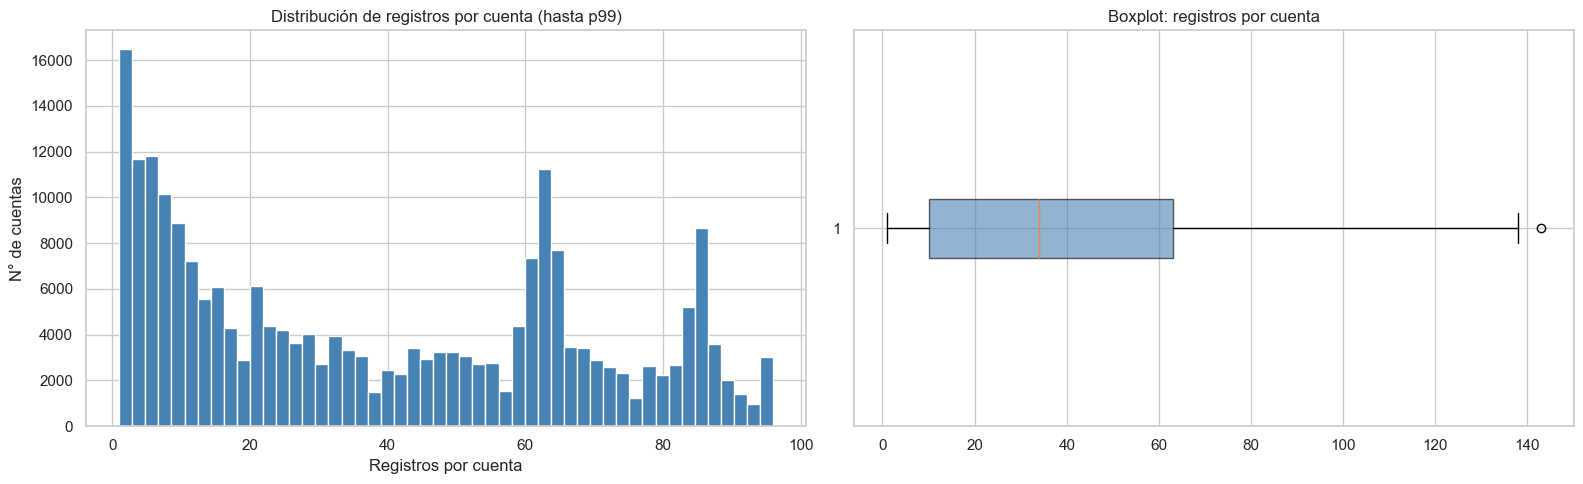


=== Estadísticas de registros por cuenta ===
count   228,563.0000
mean         38.7127
std          29.5204
min           1.0000
25%          10.0000
50%          34.0000
75%          63.0000
max         143.0000


In [26]:
# Estadísticas por cuenta corriente
if 'IdCtaCte' in df.columns:
    n_cuentas = df['IdCtaCte'].nunique()
    print(f'Cuentas corrientes únicas (IdCtaCte): {n_cuentas:,}')
    print(f'Promedio de registros por cuenta    : {len(df)/n_cuentas:.2f}')

    # Registros por cuenta
    registros_x_cuenta = df['IdCtaCte'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    registros_x_cuenta.clip(upper=registros_x_cuenta.quantile(0.99)).hist(
        bins=50, ax=axes[0], color='steelblue', edgecolor='white'
    )
    axes[0].set_title('Distribución de registros por cuenta (hasta p99)')
    axes[0].set_xlabel('Registros por cuenta')
    axes[0].set_ylabel('N° de cuentas')

    axes[1].boxplot(registros_x_cuenta, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1].set_title('Boxplot: registros por cuenta')

    plt.tight_layout()
    plt.show()

    print('\n=== Estadísticas de registros por cuenta ===')
    print(registros_x_cuenta.describe().to_string())

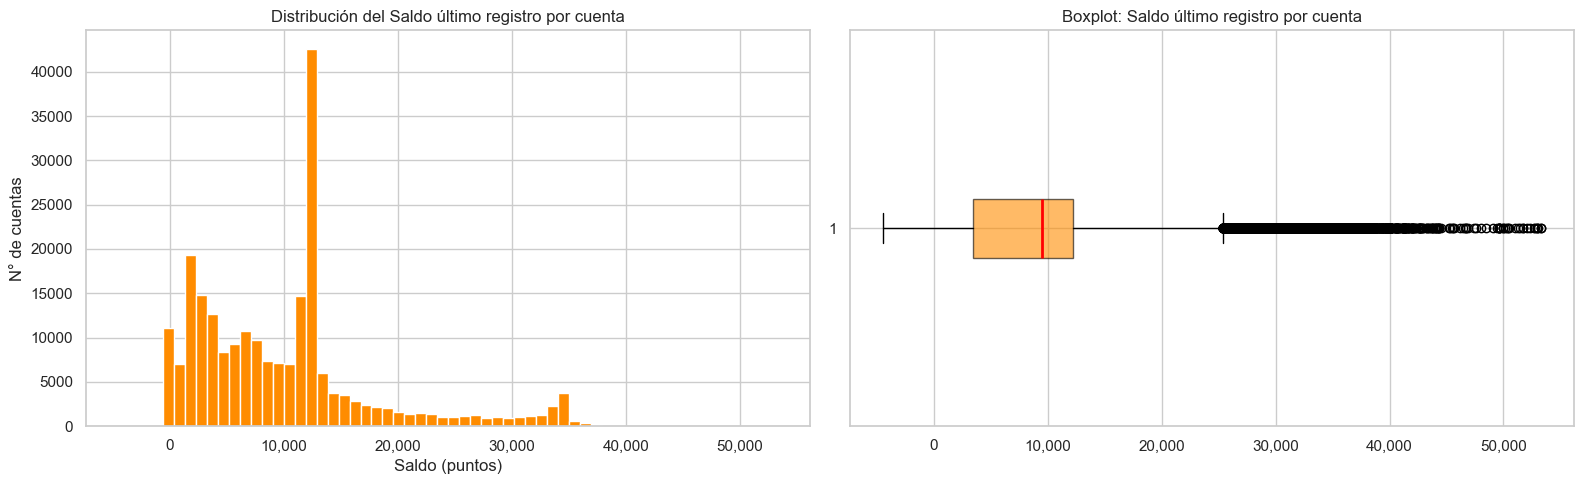

=== Estadísticas del Saldo último registro por cuenta ===
count   228,562.0000
mean     10,075.2073
std       8,088.7381
min      -4,450.0000
25%       3,500.0000
50%       9,500.0000
75%      12,250.0000
max      53,300.0000

Cuentas con saldo = 0 : 10,738 (4.70%)
Cuentas con saldo < 0 : 2 (0.00%)


In [27]:
# Saldo último registro por cuenta (snapshot del saldo actual)
if 'IdCtaCte' in df.columns and 'Saldo' in df.columns and 'FechaTrans' in df.columns:
    df_sorted = df.dropna(subset=['FechaTrans']).sort_values('FechaTrans')
    saldo_actual = df_sorted.groupby('IdCtaCte')['Saldo'].last()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    saldo_actual.hist(bins=60, ax=axes[0], color='darkorange', edgecolor='white')
    axes[0].set_title('Distribución del Saldo último registro por cuenta')
    axes[0].set_xlabel('Saldo (puntos)')
    axes[0].set_ylabel('N° de cuentas')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    axes[1].boxplot(saldo_actual.dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor='darkorange', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_title('Boxplot: Saldo último registro por cuenta')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    plt.tight_layout()
    plt.show()

    print('=== Estadísticas del Saldo último registro por cuenta ===')
    print(saldo_actual.describe().to_string())

    cuentas_saldo_cero = (saldo_actual == 0).sum()
    cuentas_saldo_neg  = (saldo_actual < 0).sum()
    print(f'\nCuentas con saldo = 0 : {cuentas_saldo_cero:,} ({cuentas_saldo_cero/n_cuentas*100:.2f}%)')
    print(f'Cuentas con saldo < 0 : {cuentas_saldo_neg:,} ({cuentas_saldo_neg/n_cuentas*100:.2f}%)')

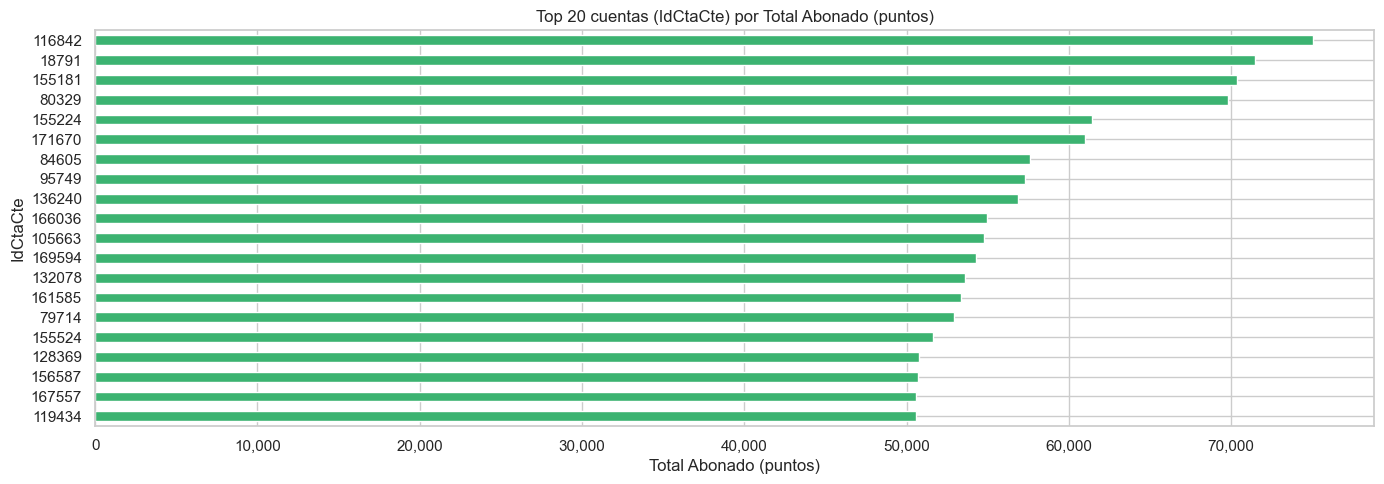

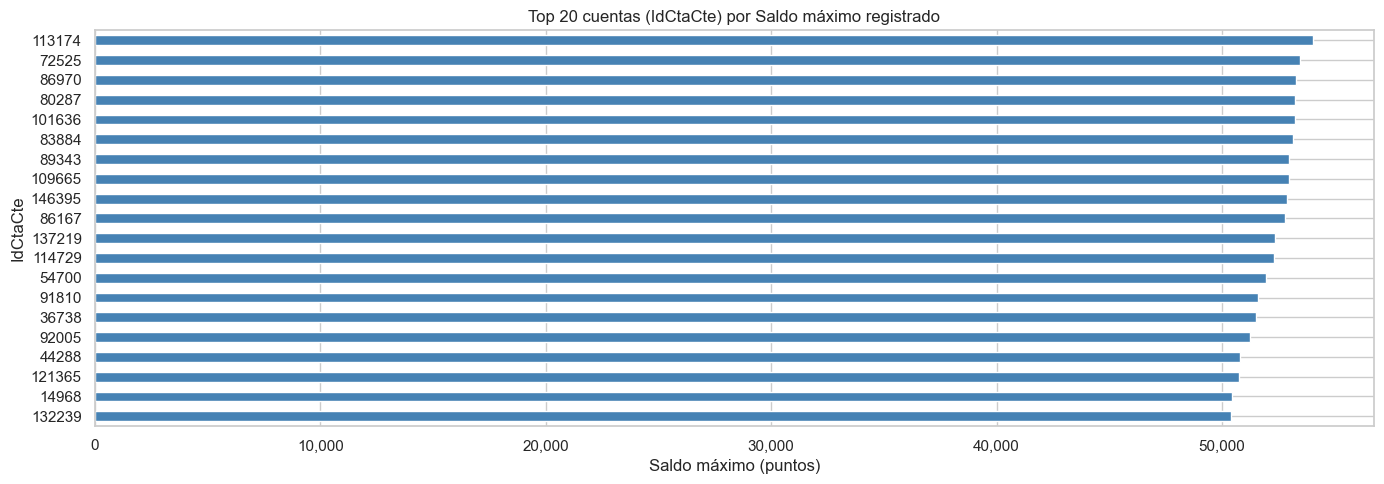

In [28]:
# Top 20 cuentas por total abonado
if 'IdCtaCte' in df.columns and 'Abono' in df.columns:
    top_cuentas_abono = df.groupby('IdCtaCte')['Abono'].sum().sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(14, 5))
    top_cuentas_abono.sort_values().plot(kind='barh', ax=ax, color='mediumseagreen', edgecolor='white')
    ax.set_title('Top 20 cuentas (IdCtaCte) por Total Abonado (puntos)', fontsize=12)
    ax.set_xlabel('Total Abonado (puntos)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.show()

# Top 20 cuentas por mayor saldo
if 'IdCtaCte' in df.columns and 'Saldo' in df.columns:
    top_cuentas_saldo = df.groupby('IdCtaCte')['Saldo'].max().sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(14, 5))
    top_cuentas_saldo.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Top 20 cuentas (IdCtaCte) por Saldo máximo registrado', fontsize=12)
    ax.set_xlabel('Saldo máximo (puntos)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.show()

## 11. Análisis de Correlaciones

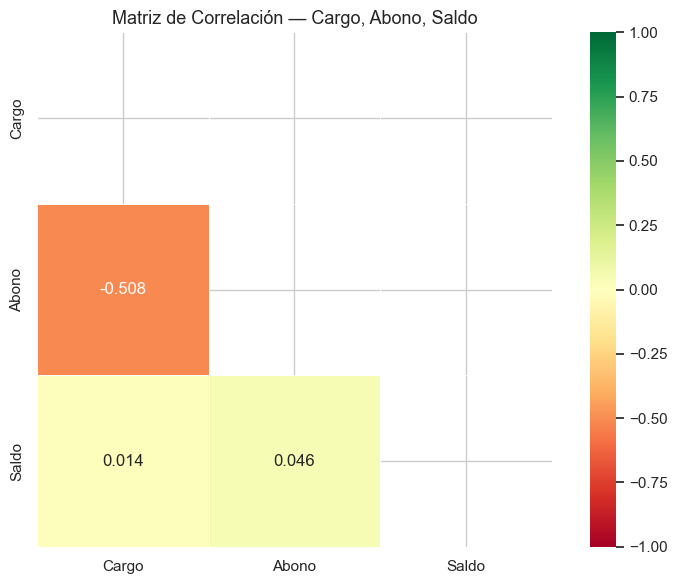

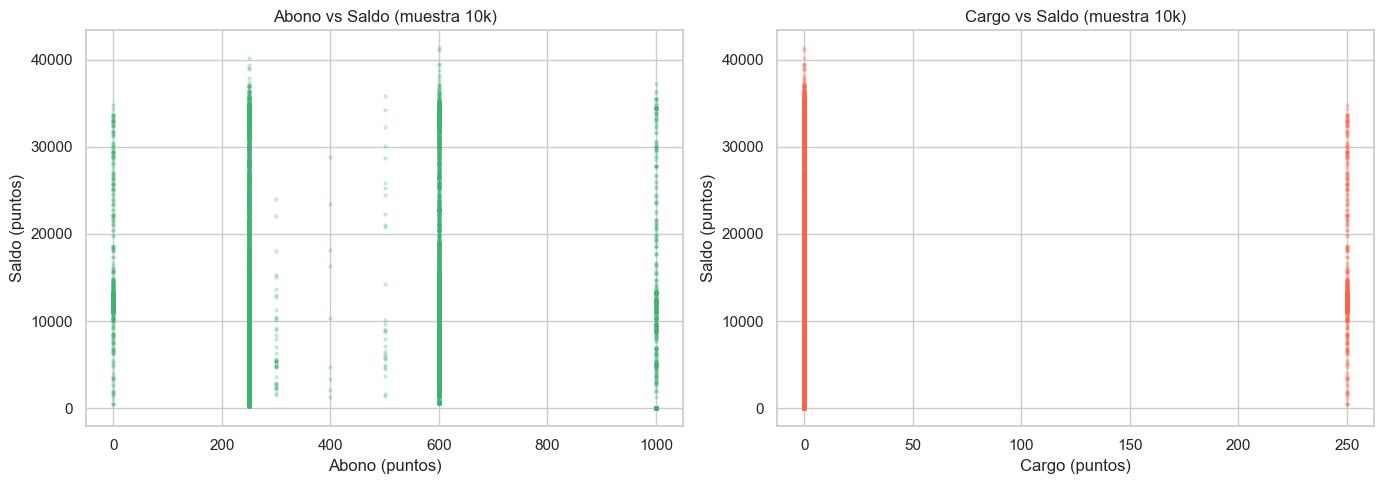

In [29]:
cols_corr = [c for c in ['Cargo', 'Abono', 'Saldo'] if c in df.columns]

if len(cols_corr) > 1:
    corr_matrix = df[cols_corr].corr()

    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.3f',
        cmap='RdYlGn', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5, ax=ax
    )
    ax.set_title('Matriz de Correlación — Cargo, Abono, Saldo', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Scatter Abono vs Saldo (muestra)
    muestra = df[['Abono', 'Cargo', 'Saldo']].dropna().sample(
        min(10_000, len(df)), random_state=42
    )
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(muestra['Abono'], muestra['Saldo'],
                    alpha=0.2, s=5, color='mediumseagreen')
    axes[0].set_title('Abono vs Saldo (muestra 10k)')
    axes[0].set_xlabel('Abono (puntos)')
    axes[0].set_ylabel('Saldo (puntos)')

    axes[1].scatter(muestra['Cargo'], muestra['Saldo'],
                    alpha=0.2, s=5, color='tomato')
    axes[1].set_title('Cargo vs Saldo (muestra 10k)')
    axes[1].set_xlabel('Cargo (puntos)')
    axes[1].set_ylabel('Saldo (puntos)')

    plt.tight_layout()
    plt.show()

## 12. Detección de Outliers

In [30]:
def detectar_outliers_iqr(serie, nombre):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = serie[(serie < lower) | (serie > upper)]
    return {
        'Columna': nombre,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Límite inferior': lower,
        'Límite superior': upper,
        'N° outliers': len(outliers),
        '% outliers': round(len(outliers) / len(serie) * 100, 2)
    }

cols_outlier = [c for c in ['Cargo', 'Abono', 'Saldo'] if c in df.columns]
resumen_outliers = pd.DataFrame([
    detectar_outliers_iqr(df[c].dropna(), c) for c in cols_outlier
])

print('=== Detección de Outliers (método IQR) ===')
display(resumen_outliers.set_index('Columna').style.format('{:,.2f}'))

=== Detección de Outliers (método IQR) ===


,Q1,Q3,IQR,Límite inferior,Límite superior,N° outliers,% outliers
Columna,,,,,,,
Cargo,0.00,0.00,0.00,0.00,0.00,"1,008,261.00",11.39
Abono,250.00,600.00,350.00,-275.00,"1,125.00",19.00,0.00
Saldo,"6,500.00","14,600.00","8,100.00","-5,650.00","26,750.00","1,098,861.00",12.42


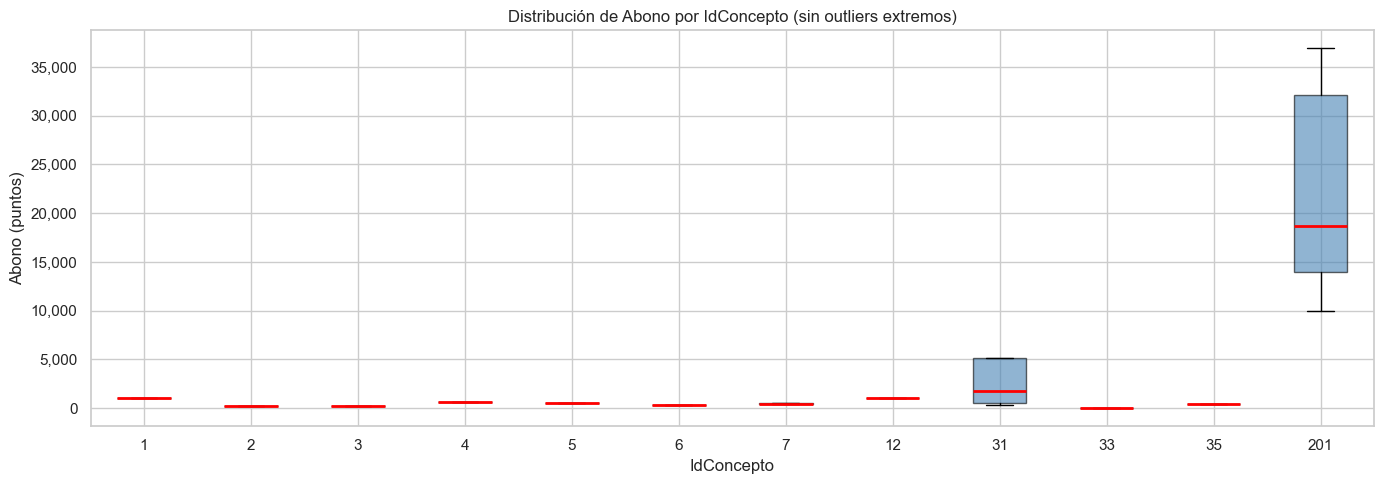

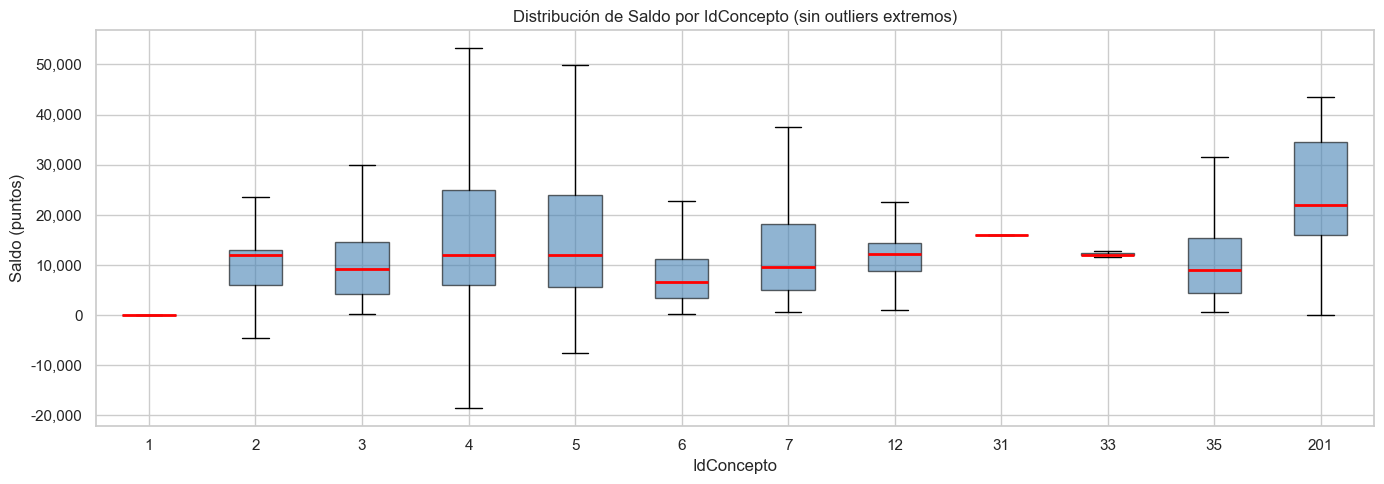

In [31]:
# Boxplots comparativos por IdConcepto
if 'IdConcepto' in df.columns:
    for col_monto in ['Abono', 'Saldo']:
        if col_monto not in df.columns:
            continue
        conceptos = sorted(df['IdConcepto'].dropna().unique())
        grupos = [
            df.loc[df['IdConcepto'] == c, col_monto].dropna()
            for c in conceptos
        ]
        grupos = [g for g in grupos if len(g) > 0]
        etiquetas = [str(int(c)) for c in conceptos if len(df.loc[df['IdConcepto'] == c]) > 0]

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.boxplot(grupos, labels=etiquetas, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6),
                   medianprops=dict(color='red', linewidth=2),
                   showfliers=False)
        ax.set_title(f'Distribución de {col_monto} por IdConcepto (sin outliers extremos)', fontsize=12)
        ax.set_xlabel('IdConcepto')
        ax.set_ylabel(f'{col_monto} (puntos)')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        plt.tight_layout()
        plt.show()

## 13. Análisis de Duplicados

In [32]:
total_dups = df.duplicated().sum()
print(f'Filas completamente duplicadas: {total_dups:,} ({total_dups/len(df)*100:.4f}%)')

# Verificar unicidad de claves de negocio naturales
claves_a_verificar = [
    ['IdTrans'],
    ['IdCtaCte', 'IdTrans'],
    ['IdCtaCte', 'FechaTrans', 'IdConcepto'],
    ['IdCtaCte', 'FechaTrans', 'Abono', 'Cargo'],
]

for clave in claves_a_verificar:
    cols_clave = [c for c in clave if c in df.columns]
    if len(cols_clave) == len(clave):
        dups = df.duplicated(subset=cols_clave).sum()
        print(f'Duplicados por {cols_clave}: {dups:,} ({dups/len(df)*100:.4f}%)')

Filas completamente duplicadas: 0 (0.0000%)
Duplicados por ['IdTrans']: 8,848,040 (99.9973%)
Duplicados por ['IdCtaCte', 'IdTrans']: 0 (0.0000%)
Duplicados por ['IdCtaCte', 'FechaTrans', 'IdConcepto']: 32,384 (0.3660%)
Duplicados por ['IdCtaCte', 'FechaTrans', 'Abono', 'Cargo']: 117,148 (1.3240%)


IdTrans únicos: 241


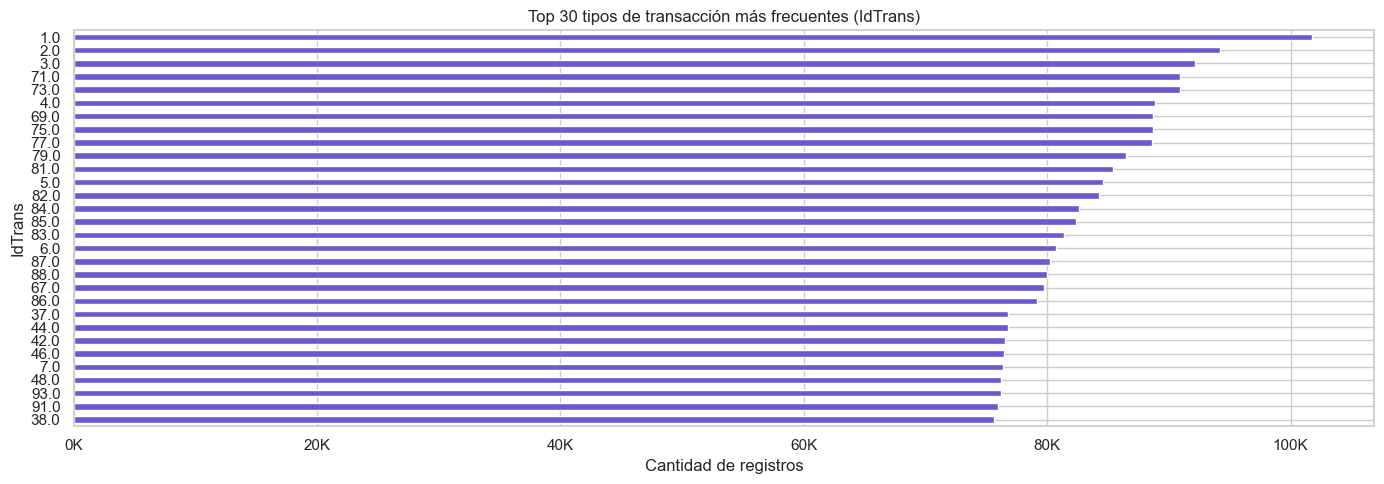

In [33]:
# Análisis de IdTrans: distribución de tipos de transacción
if 'IdTrans' in df.columns:
    freq_trans = df['IdTrans'].value_counts().head(30)

    print(f'IdTrans únicos: {df["IdTrans"].nunique()}')

    fig, ax = plt.subplots(figsize=(14, 5))
    freq_trans.sort_values().plot(kind='barh', ax=ax, color='slateblue', edgecolor='white')
    ax.set_title('Top 30 tipos de transacción más frecuentes (IdTrans)', fontsize=12)
    ax.set_xlabel('Cantidad de registros')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    plt.tight_layout()
    plt.show()

## 14. Análisis Combinado: Evolución del Saldo por Concepto

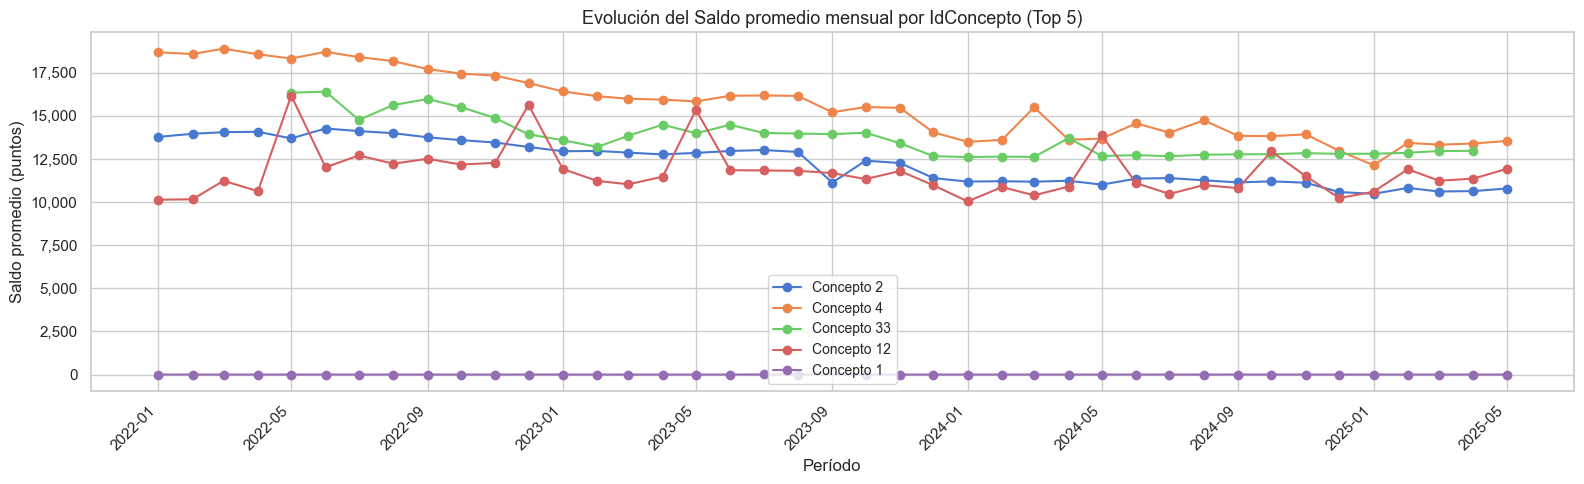

In [34]:
# Saldo promedio mensual por los conceptos más frecuentes
if 'FechaTrans' in df.columns and 'IdConcepto' in df.columns and 'Saldo' in df.columns:
    df_evo = df.dropna(subset=['FechaTrans', 'IdConcepto']).copy()
    df_evo['FECHA_PERIODO'] = df_evo['FechaTrans'].dt.to_period('M').dt.to_timestamp()

    top_conceptos = df_evo['IdConcepto'].value_counts().head(5).index.tolist()

    saldo_evo = df_evo[df_evo['IdConcepto'].isin(top_conceptos)] \
        .groupby(['FECHA_PERIODO', 'IdConcepto'])['Saldo'] \
        .mean() \
        .reset_index()

    fig, ax = plt.subplots(figsize=(16, 5))
    for concepto in top_conceptos:
        sub = saldo_evo[saldo_evo['IdConcepto'] == concepto]
        ax.plot(sub['FECHA_PERIODO'], sub['Saldo'], marker='o', linewidth=1.5,
                label=f'Concepto {int(concepto)}')

    ax.set_title('Evolución del Saldo promedio mensual por IdConcepto (Top 5)', fontsize=13)
    ax.set_xlabel('Período')
    ax.set_ylabel('Saldo promedio (puntos)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

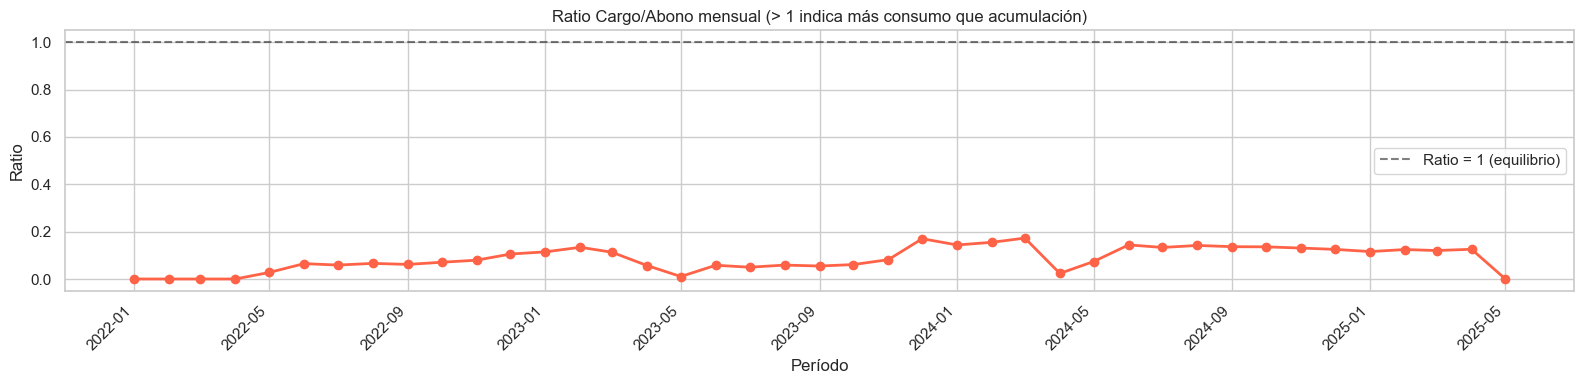

In [35]:
# Ratio Cargo/Abono mensual
if 'FECHA_PERIODO' in df_evo.columns:
    ratio_mes = df_evo.groupby('FECHA_PERIODO').agg(
        Total_Abono=('Abono', 'sum'),
        Total_Cargo=('Cargo', 'sum')
    ).reset_index()
    ratio_mes['Ratio_Cargo_Abono'] = np.where(
        ratio_mes['Total_Abono'] > 0,
        ratio_mes['Total_Cargo'] / ratio_mes['Total_Abono'],
        np.nan
    )

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(ratio_mes['FECHA_PERIODO'], ratio_mes['Ratio_Cargo_Abono'],
            marker='o', color='tomato', linewidth=2)
    ax.axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Ratio = 1 (equilibrio)')
    ax.set_title('Ratio Cargo/Abono mensual (> 1 indica más consumo que acumulación)', fontsize=12)
    ax.set_xlabel('Período')
    ax.set_ylabel('Ratio')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 15. Resumen Ejecutivo

In [36]:
print('=' * 65)
print('       RESUMEN EJECUTIVO — EDA P18 TRANSACCION DIARIO')
print('=' * 65)

print(f'\n[VOLUMEN]')
print(f'  Total registros         : {len(df):,}')
print(f'  Total columnas          : {df.shape[1]}')

if 'FechaTrans' in df.columns:
    ft = df['FechaTrans'].dropna()
    print(f'  Rango FechaTrans        : {ft.min().date()} → {ft.max().date()}')

if 'IdCtaCte' in df.columns:
    print(f'  Cuentas únicas          : {df["IdCtaCte"].nunique():,}')

if 'IdConcepto' in df.columns:
    print(f'  Conceptos únicos        : {df["IdConcepto"].nunique()}')

if 'ConceptoDescripcion' in df.columns:
    print(f'  Descripciones únicas    : {df["ConceptoDescripcion"].nunique()}')

if 'IdTrans' in df.columns:
    print(f'  Tipos transacción únicos: {df["IdTrans"].nunique()}')

print(f'\n[PUNTOS GLOBALES]')
for col in ['Abono', 'Cargo', 'Saldo']:
    if col in df.columns:
        print(f'  {col}:')
        print(f'    Total   : {df[col].sum():>20,.0f} pts')
        print(f'    Promedio: {df[col].mean():>20,.2f} pts')
        print(f'    Mediana : {df[col].median():>20,.2f} pts')

print(f'\n[CALIDAD DE DATOS]')
pct_nulos_total = df.isnull().sum().sum() / (len(df) * df.shape[1]) * 100
print(f'  Tasa de nulidad global     : {pct_nulos_total:.4f}%')
if 'FechaVencTrans' in df.columns:
    pct_venc_nulo = df['FechaVencTrans'].isnull().sum() / len(df) * 100
    print(f'  FechaVencTrans nulos       : {df["FechaVencTrans"].isnull().sum():,} ({pct_venc_nulo:.2f}%)')
print(f'  Duplicados exactos         : {df.duplicated().sum():,}')

print(f'\n[COBERTURA TEMPORAL]')
if 'PeriodoTrans' in df.columns:
    periodos = sorted(df['PeriodoTrans'].dropna().unique())
    print(f'  Períodos cubiertos: {len(periodos)} ({int(periodos[0])} → {int(periodos[-1])})')

if 'Estado' in df.columns:
    print(f'\n[ESTADO]')
    for v, n in df['Estado'].value_counts(dropna=False).items():
        print(f'  Estado {v}: {n:,} ({n/len(df)*100:.2f}%)')

print('\n' + '=' * 65)

       RESUMEN EJECUTIVO — EDA P18 TRANSACCION DIARIO

[VOLUMEN]
  Total registros         : 8,848,282
  Total columnas          : 11
  Rango FechaTrans        : 2022-01-11 → 2025-05-23
  Cuentas únicas          : 228,563
  Conceptos únicos        : 12
  Descripciones únicas    : 256
  Tipos transacción únicos: 241

[PUNTOS GLOBALES]
  Abono:
    Total   :        3,026,560,571 pts
    Promedio:               342.05 pts
    Mediana :               250.00 pts
  Cargo:
    Total   :          252,065,250 pts
    Promedio:                28.49 pts
    Mediana :                 0.00 pts
  Saldo:
    Total   :      114,733,209,786 pts
    Promedio:            12,966.72 pts
    Mediana :            12,000.00 pts

[CALIDAD DE DATOS]
  Tasa de nulidad global     : 1.0359%
  FechaVencTrans nulos       : 1,008,270 (11.40%)
  Duplicados exactos         : 0

[COBERTURA TEMPORAL]
  Períodos cubiertos: 41 (202201 → 202505)

[ESTADO]
  Estado 1.0: 8,848,281 (100.00%)
  Estado nan: 1 (0.00%)

